In [146]:
# ─── 0. Imports & Global Style ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import re, ast
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

import seaborn as sns
import networkx as nx
from sklearn.preprocessing import LabelEncoder

# ── Nature Communications colour palette ─────────────────────────────────────
# Primary: muted blue, green, orange, red, purple, grey
NC_COLORS = {
    'blue':   '#4477AA',
    'cyan':   '#66CCEE',
    'green':  '#228833',
    'yellow': '#CCBB44',
    'red':    '#EE6677',
    'purple': '#AA3377',
    'grey':   '#BBBBBB',
    'navy':   '#223F5E',
    'orange': '#E07030',
    'teal':   '#3D8B8B',
}
NC_LIST = [NC_COLORS[k] for k in ['blue','red','green','yellow','purple','cyan','orange','teal','grey']]
NC_DIV  = ['#4477AA','#77AADD','#BBCCEE','#F7F7F7','#FFCCCC','#EE9988','#BB4444']

MODEL_COLORS = {'M1': NC_COLORS['blue'],  'M2': NC_COLORS['green'],
                'M3': NC_COLORS['orange'],'M4': NC_COLORS['red']}
ACTION_COLORS = {'a_next':  NC_COLORS['blue'],  'a_eval':  NC_COLORS['cyan'],
                 'a_mitig': NC_COLORS['yellow'], 'a_accept':NC_COLORS['green'],
                 'a_reject':NC_COLORS['red']}
DECISION_COLORS = {'a_accept': NC_COLORS['green'], 'a_reject': NC_COLORS['red']}

# ── Global matplotlib settings (NC style) ────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':        'Arial',
    'font.size':           8,
    'axes.titlesize':      9,
    'axes.labelsize':      8,
    'xtick.labelsize':     7,
    'ytick.labelsize':     7,
    'legend.fontsize':     7,
    'axes.linewidth':      0.6,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'xtick.major.width':   0.6,
    'ytick.major.width':   0.6,
    'xtick.major.size':    3,
    'ytick.major.size':    3,
    'lines.linewidth':     1.2,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
    'pdf.fonttype':        42,   # embeds fonts
})

OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

def savefig(name):
    plt.savefig(OUTPUT_DIR / f'{name}.pdf')
    plt.savefig(OUTPUT_DIR / f'{name}.png', dpi=300)
    plt.show()

In [147]:

CSV_PATH = 'E:\\pythonProject\\cross_new\\results_v4.csv'
df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} episodes | columns: {df.columns.tolist()}')

# ── parse candidate_pool
df['pool_parsed'] = df['candidate_pool'].apply(ast.literal_eval)
# df['initial_model'] = df['pool_parsed'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'Unknown')
df['pool_size']   = df['pool_parsed'].apply(len)
df['pool_str']    = df['pool_parsed'].apply(lambda x: '_'.join(sorted(x)))

# ── parse action counts from action_path
df['n_eval']   = df['action_path'].str.count('a_eval')
df['n_mitig']  = df['action_path'].str.count('a_mitig')
df['n_next']   = df['action_path'].str.count('a_next')
df['n_reject_mid'] = df['action_path'].apply(
    lambda p: max(0, p.count('a_reject') - (1 if p.split('->')[-1].strip().startswith('Reject') else 0)))

# ── model transition: initial → final
df['model_changed'] = df['initial_model'] != df['final_model']

# ── parse final_state components
def parse_final_state(fs):
    parts = str(fs).split('_')
    if len(parts) >= 3:
        return parts[0], parts[1], parts[2]
    return fs, '', ''
df[['decision','fs_model','fs_subtype']] = pd.DataFrame(
    df['final_state'].apply(parse_final_state).tolist(), index=df.index)

# ── input feature columns (new test script)
INPUT_COLS = [c for c in df.columns if c.startswith('input_')]
HAS_INPUT  = len(INPUT_COLS) > 0
print(f'Input feature columns: {INPUT_COLS if HAS_INPUT else "not present (old format)"}')

# ── encode categorical for correlation
le = LabelEncoder()
for col in ['initial_model','final_model','final_action','dominant_risk','decision']:
    df[col+'_enc'] = le.fit_transform(df[col].astype(str))

df.head(3)

Loaded 33,333 episodes | columns: ['episode', 'candidate_pool', 'initial_model', 'final_model', 'final_state', 'action_path', 'final_action', 'total_reward', 'total_steps', 'g_final', 'g_minimal', 'g_limited', 'g_high', 'g_banned', 'dominant_risk', 'input_1_d', 'input_1_b', 'input_1_r', 'input_1_c', 'input_1_k', 'input_1_m', 'input_1_m_metrics', 'input_2_d', 'input_2_b', 'input_2_r', 'input_2_c', 'input_2_k', 'input_2_m', 'input_2_m_metrics', 'input_3_d', 'input_3_b', 'input_3_r', 'input_3_c', 'input_3_k', 'input_3_m', 'input_3_m_metrics']
Input feature columns: ['input_1_d', 'input_1_b', 'input_1_r', 'input_1_c', 'input_1_k', 'input_1_m', 'input_1_m_metrics', 'input_2_d', 'input_2_b', 'input_2_r', 'input_2_c', 'input_2_k', 'input_2_m', 'input_2_m_metrics', 'input_3_d', 'input_3_b', 'input_3_r', 'input_3_c', 'input_3_k', 'input_3_m', 'input_3_m_metrics']


,episode,candidate_pool,initial_model,final_model,final_state,action_path,final_action,total_reward,total_steps,g_final,...,n_reject_mid,model_changed,decision,fs_model,fs_subtype,initial_model_enc,final_model_enc,final_action_enc,dominant_risk_enc,decision_enc
0,1,"['M4', 'M1', 'M1']",M4,M1,Accept_M1_a,s0 -> a_next -> M4 -> a_mitig -> M2 -> a_mitig...,a_accept,68.8951,7,"[0.9262, 0.0141, 0.0017, 0.0579]",...,0,True,Accept,M1,a,3,0,0,3,0
1,2,"['M3', 'M2', 'M4']",M3,M2,Reject_M2_d,s0 -> a_next -> M3 -> a_mitig -> M2 -> a_mitig...,a_reject,-177.6987,21,"[0.0003, 0.017, 0.9581, 0.0245]",...,2,True,Reject,M2,d,2,1,1,1,1
2,3,"['M4', 'M2', 'M1']",M4,M1,Accept_M1_a,s0 -> a_next -> M4 -> a_mitig -> M2 -> a_mitig...,a_accept,-13.6542,14,"[0.9817, 0.0021, 0.0162, 0.0]",...,1,True,Accept,M1,a,3,0,0,3,0


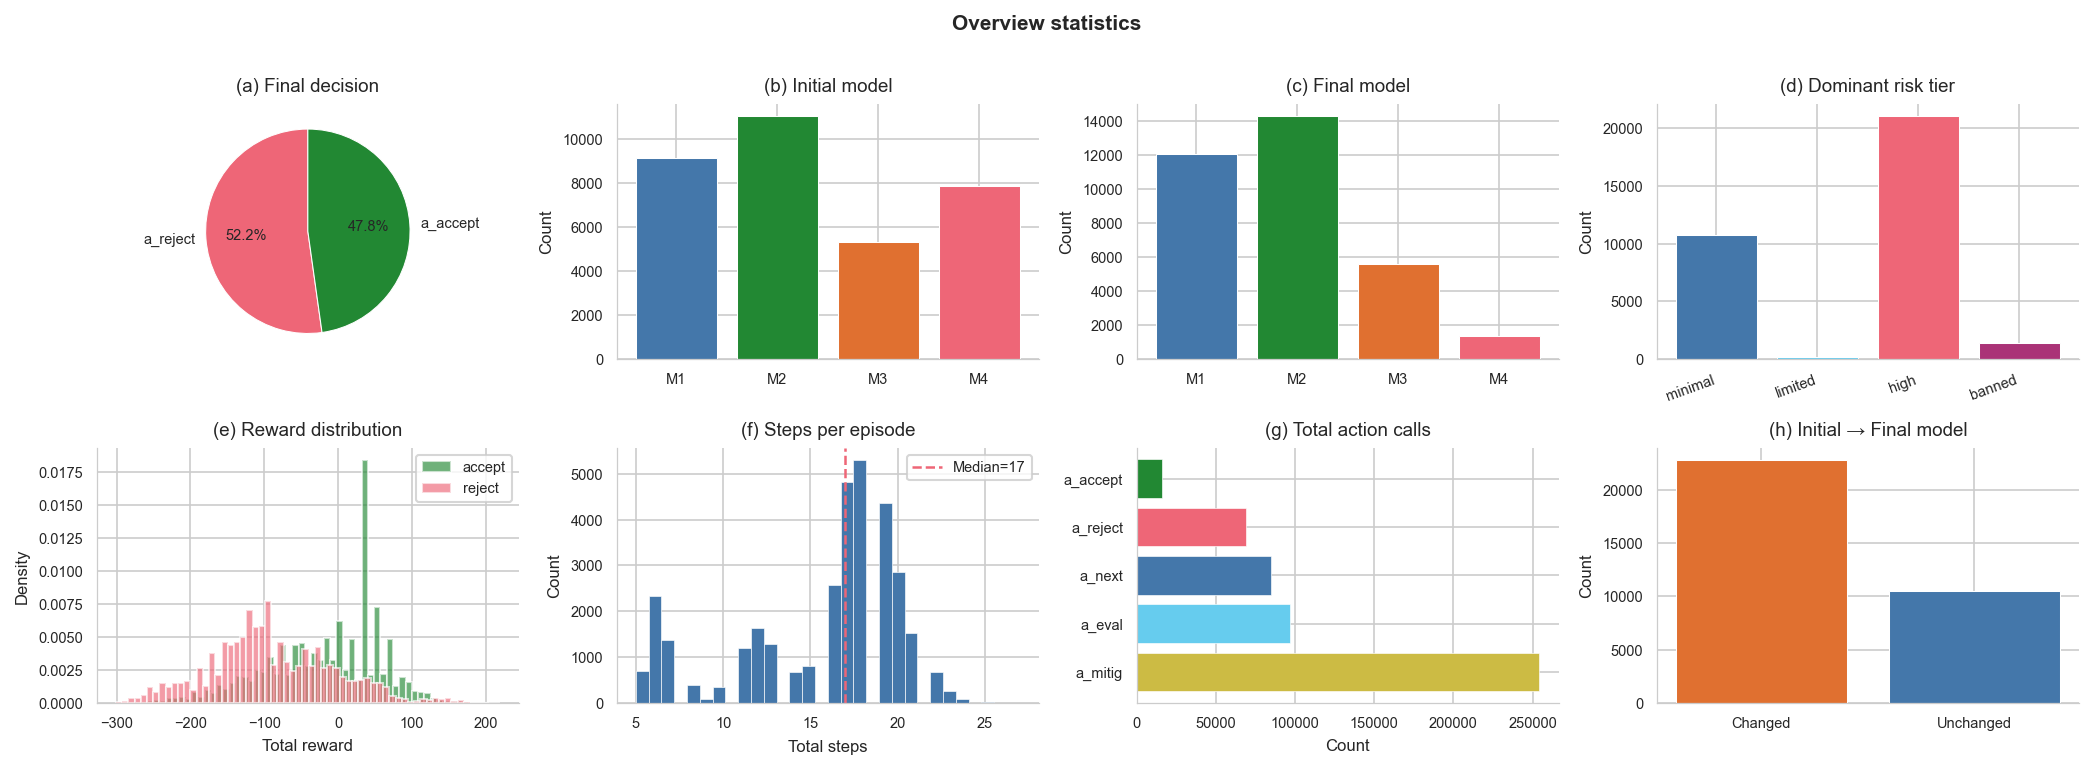

In [148]:
# ─── 1.1 Global KPI Panel ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
fig.suptitle('Overview statistics', fontsize=10, fontweight='bold', y=1.01)

# (a) final_action pie
ax = axes[0, 0]
cnt = df['final_action'].value_counts()
ax.pie(cnt.values, labels=cnt.index, colors=[DECISION_COLORS.get(k, '#aaa') for k in cnt.index],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 7},
       wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'})
ax.set_title('(a) Final decision')

# (b) initial_model bar
ax = axes[0, 1]
cnt_im = df['initial_model'].value_counts().reindex(['M1','M2','M3','M4'])
ax.bar(cnt_im.index, cnt_im.values,
       color=[MODEL_COLORS[m] for m in cnt_im.index], edgecolor='white', linewidth=0.5)
ax.set_title('(b) Initial model')
ax.set_ylabel('Count')

# (c) final_model bar
ax = axes[0, 2]
cnt_fm = df['final_model'].value_counts().reindex(['M1','M2','M3','M4'])
ax.bar(cnt_fm.index, cnt_fm.values,
       color=[MODEL_COLORS[m] for m in cnt_fm.index], edgecolor='white', linewidth=0.5)
ax.set_title('(c) Final model')
ax.set_ylabel('Count')

# (d) dominant_risk bar
ax = axes[0, 3]
order = ['minimal','limited','high','banned']
risk_colors = ['#4477AA','#66CCEE','#EE6677','#AA3377']
cnt_dr = df['dominant_risk'].value_counts().reindex(order, fill_value=0)
ax.bar(cnt_dr.index, cnt_dr.values, color=risk_colors, edgecolor='white', linewidth=0.5)
ax.set_title('(d) Dominant risk tier')
ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_ylabel('Count')

# (e) reward dist
ax = axes[1, 0]
for act, col in DECISION_COLORS.items():
    sub = df[df['final_action'] == act]['total_reward']
    ax.hist(sub, bins=60, alpha=0.65, color=col, label=act.replace('a_',''), density=True)
ax.set_title('(e) Reward distribution')
ax.set_xlabel('Total reward')
ax.set_ylabel('Density')
ax.legend()

# (f) total_steps dist
ax = axes[1, 1]
ax.hist(df['total_steps'], bins=30, color=NC_COLORS['blue'], edgecolor='white', linewidth=0.3)
ax.axvline(df['total_steps'].median(), color=NC_COLORS['red'], lw=1.2, ls='--', label=f"Median={df['total_steps'].median():.0f}")
ax.set_title('(f) Steps per episode')
ax.set_xlabel('Total steps')
ax.set_ylabel('Count')
ax.legend()

# (g) action frequency
ax = axes[1, 2]
action_totals = {a: df['action_path'].str.count(a).sum() for a in ACTION_COLORS}
sorted_actions = sorted(action_totals, key=lambda x: -action_totals[x])
ax.barh(sorted_actions, [action_totals[a] for a in sorted_actions],
        color=[ACTION_COLORS[a] for a in sorted_actions], edgecolor='white', linewidth=0.3)
ax.set_title('(g) Total action calls')
ax.set_xlabel('Count')

# (h) model change frequency
ax = axes[1, 3]
mc = df['model_changed'].value_counts()
ax.bar(['Changed','Unchanged'], [mc.get(True,0), mc.get(False,0)],
       color=[NC_COLORS['orange'], NC_COLORS['blue']], edgecolor='white', linewidth=0.5)
ax.set_title('(h) Initial → Final model')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()
# savefig('01_overview')

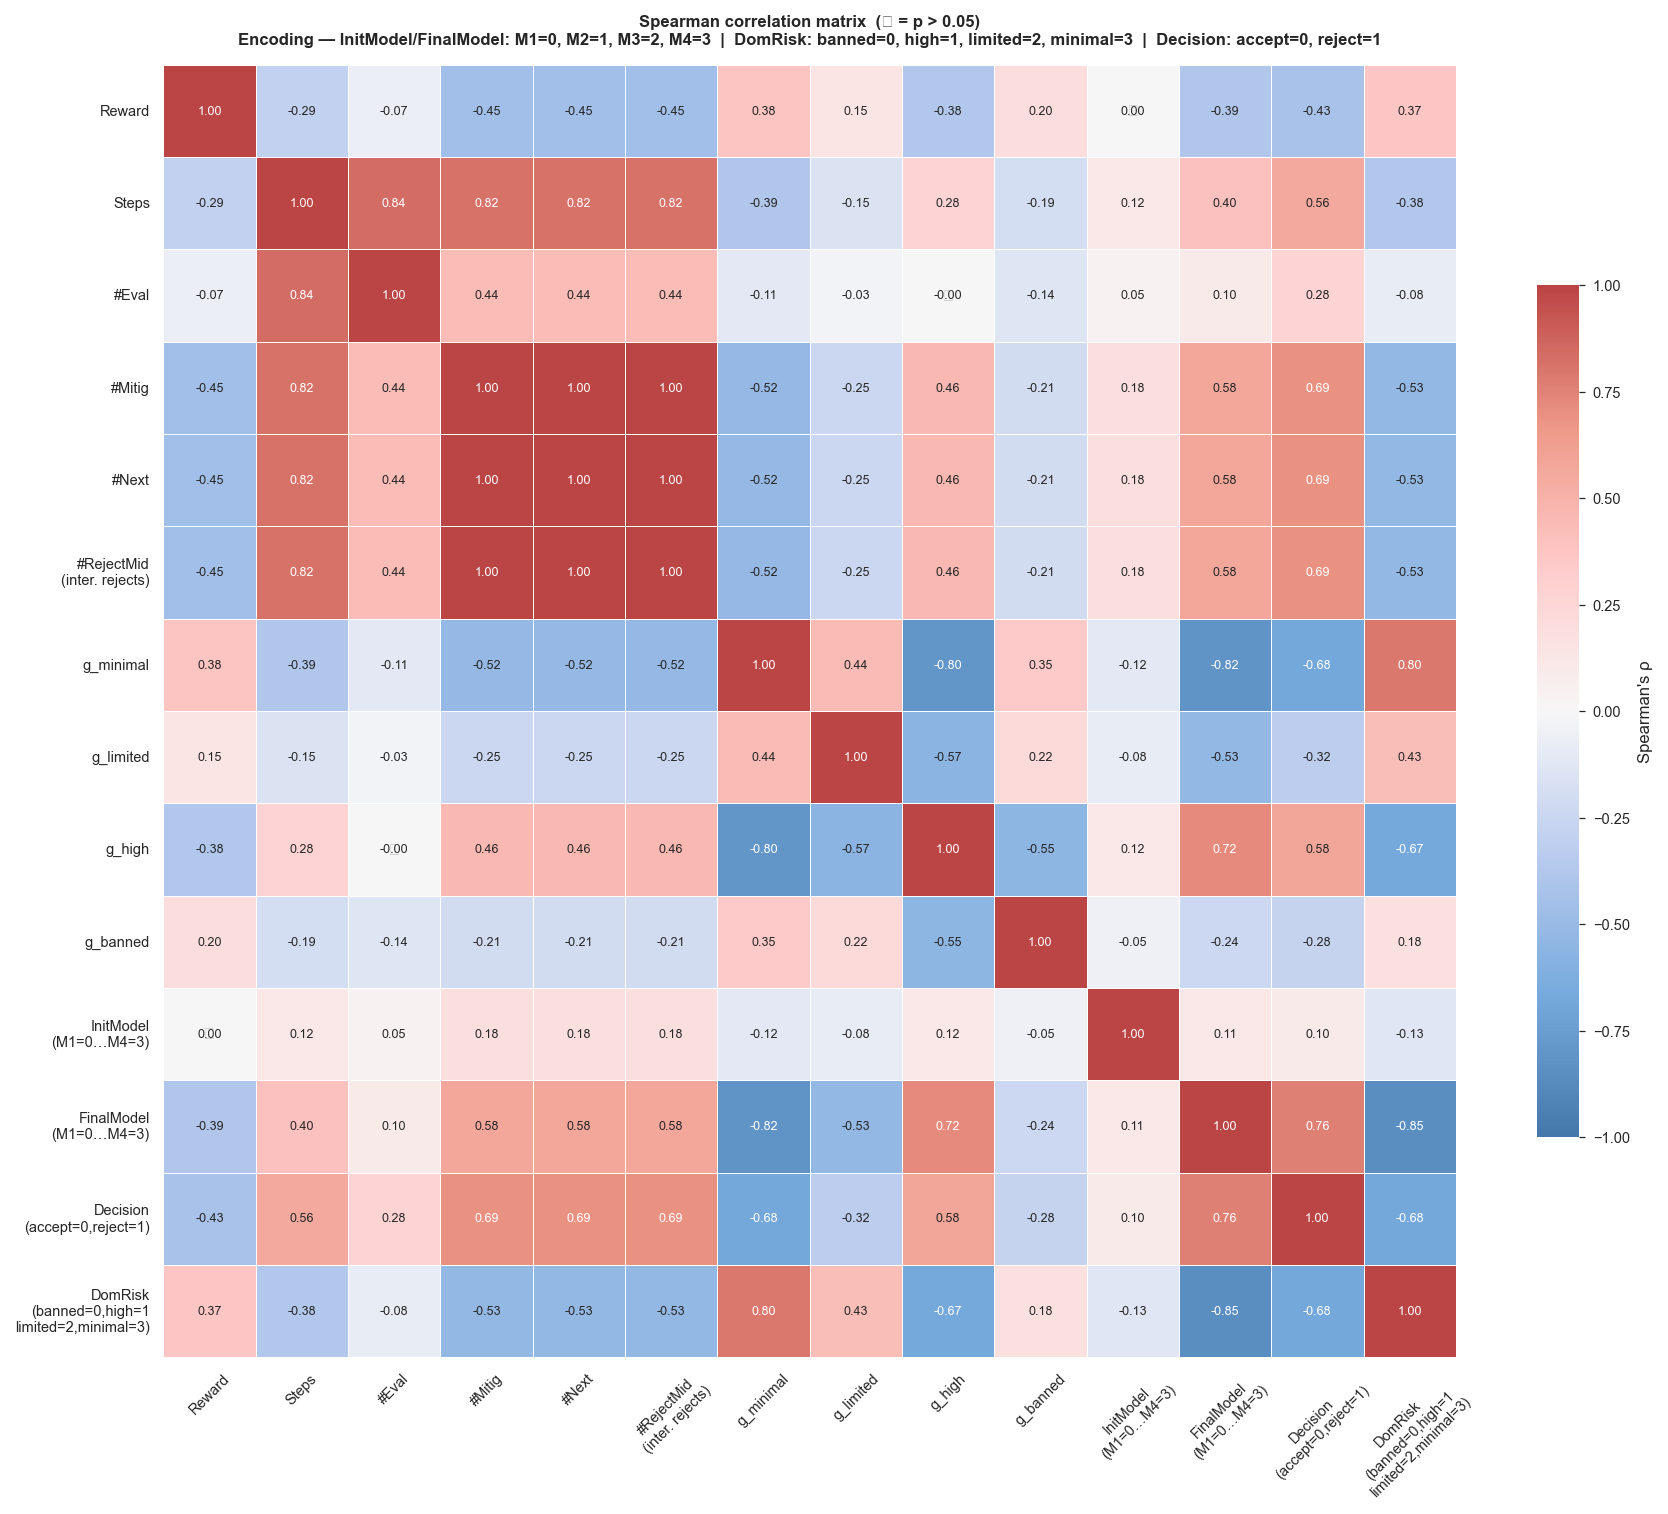

In [149]:
# ─── 2.1 Spearman Correlation Heatmap ─────────────────────────────────────────
# Encoding reference (appended to axis labels):
#   InitModel / FinalModel : M1=0, M2=1, M3=2, M4=3
#   DomRisk                : banned=0, high=1, limited=2, minimal=3
#   #RejectMid             : number of intermediate (non-terminal) rejects in path

corr_cols = ['total_reward','total_steps','n_eval','n_mitig','n_next','n_reject_mid',
             'g_minimal','g_limited','g_high','g_banned',
             'initial_model_enc','final_model_enc','final_action_enc','dominant_risk_enc']

# ── Descriptive axis labels with encoding note ────────────────────────────────
corr_labels = [
    'Reward',
    'Steps',
    '#Eval',
    '#Mitig',
    '#Next',
    '#RejectMid\n(inter. rejects)',       # intermediate rejects during episode
    'g_minimal',
    'g_limited',
    'g_high',
    'g_banned',
    'InitModel\n(M1=0…M4=3)',             # initial model tried
    'FinalModel\n(M1=0…M4=3)',            # model at final decision
    'Decision\n(accept=0,reject=1)',
    'DomRisk\n(banned=0,high=1\nlimited=2,minimal=3)',
]

corr_df  = df[corr_cols].dropna()
rho, pval = stats.spearmanr(corr_df)
rho_df    = pd.DataFrame(rho, index=corr_labels, columns=corr_labels)

# significance mask (p < 0.05)
sig_mask  = pval > 0.05

fig, ax = plt.subplots(figsize=(12, 10))
nc_div_cmap = LinearSegmentedColormap.from_list('NC_div', NC_DIV)
sns.heatmap(rho_df, ax=ax, cmap=nc_div_cmap, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 6},
            cbar_kws={'shrink': 0.65, 'label': "Spearman's ρ"})

# mark non-significant cells with ✕
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        if sig_mask[i, j] and i != j:
            ax.text(j+0.5, i+0.5, '✕', ha='center', va='center',
                    fontsize=8, color='#888888', alpha=0.6)

ax.set_title("Spearman correlation matrix  (✕ = p > 0.05)\n"             "Encoding — InitModel/FinalModel: M1=0, M2=1, M3=2, M4=3  |  "             "DomRisk: banned=0, high=1, limited=2, minimal=3  |  "             "Decision: accept=0, reject=1",
             fontsize=8, fontweight='bold', pad=10)

ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()
# savefig('02_correlation_heatmap')

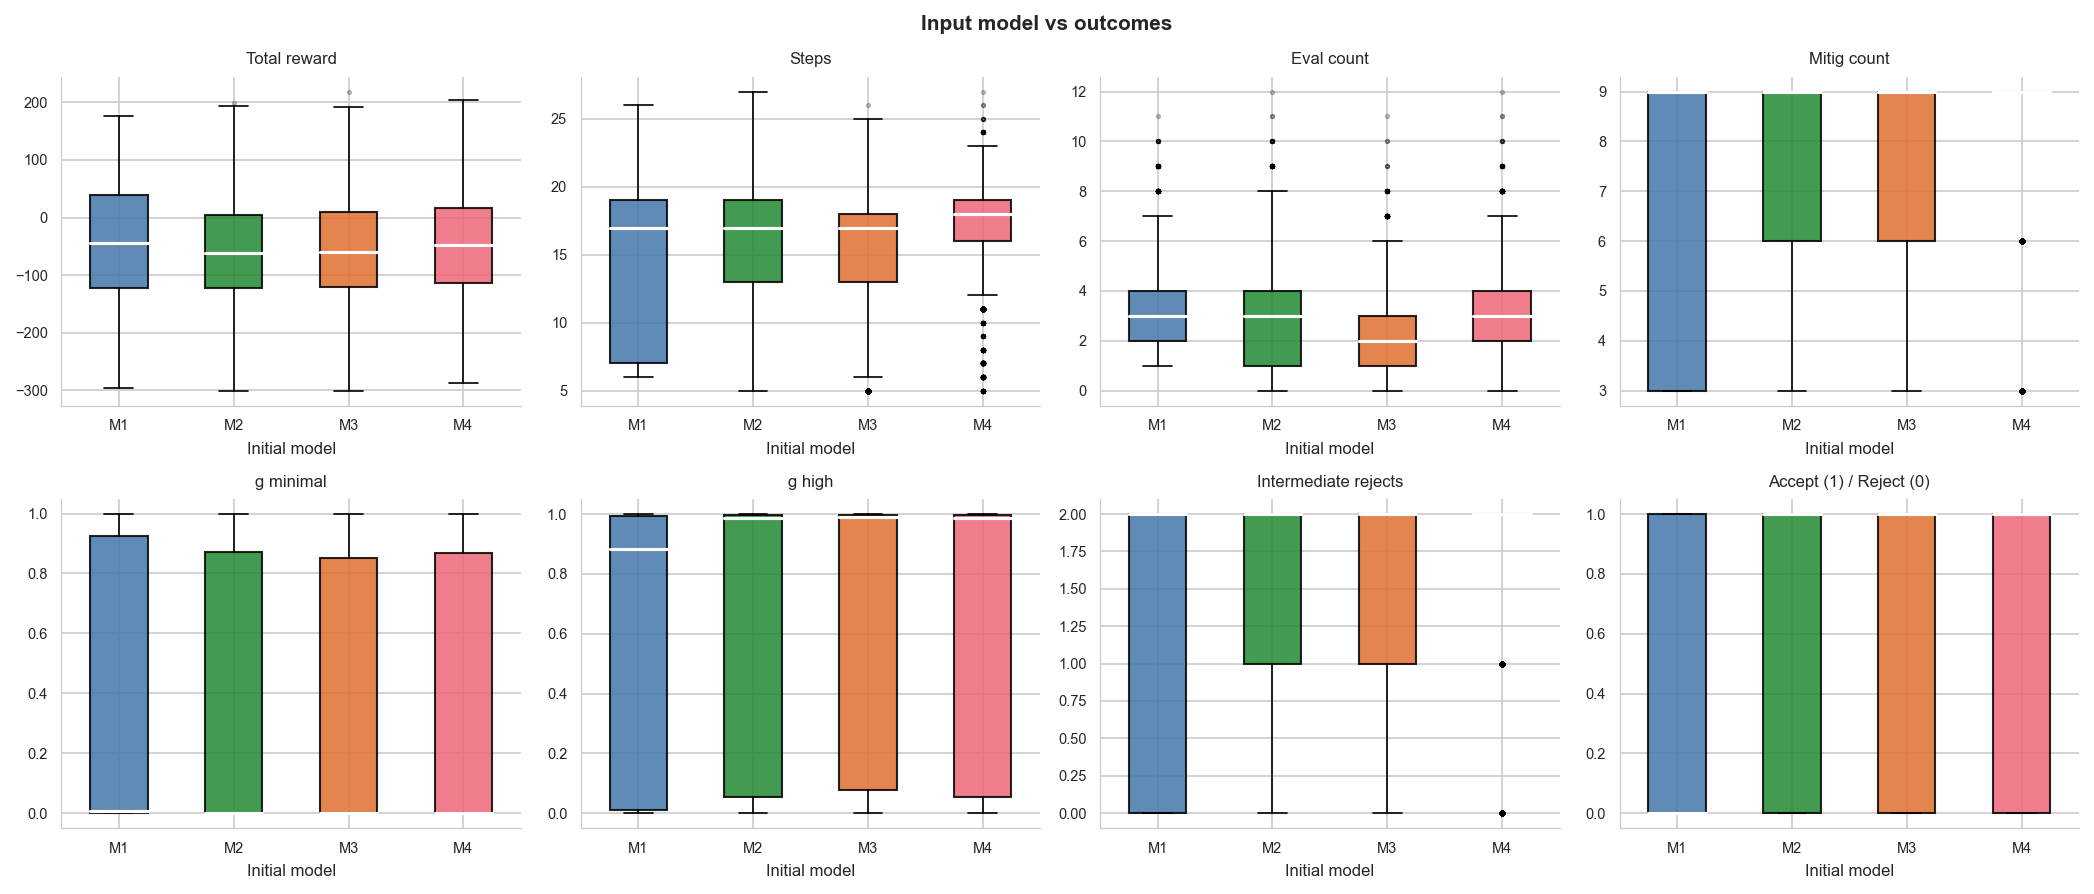

In [150]:
# ─── 2.2 Input Features vs Key Outcomes ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Input model vs outcomes', fontsize=10, fontweight='bold')

models = ['M1','M2','M3','M4']
metrics = [
    ('total_reward',    'Total reward'),
    ('total_steps',     'Steps'),
    ('n_eval',          'Eval count'),
    ('n_mitig',         'Mitig count'),
    ('g_minimal',       'g minimal'),
    ('g_high',          'g high'),
    ('n_reject_mid',    'Intermediate rejects'),
    ('final_action_enc','Accept (1) / Reject (0)'),
]

for ax, (col, label) in zip(axes.flat, metrics):
    data = [df[df['initial_model'] == m][col].values for m in models]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops={'color':'white','linewidth':1.5},
                    whiskerprops={'linewidth':0.8}, capprops={'linewidth':0.8},
                    flierprops={'marker':'o','markersize':1.5,'alpha':0.3,'linewidth':0})
    for patch, m in zip(bp['boxes'], models):
        patch.set_facecolor(MODEL_COLORS[m])
        patch.set_alpha(0.85)
    ax.set_xticklabels(models)
    ax.set_title(label, fontsize=8)
    ax.set_xlabel('Initial model')

plt.tight_layout()
plt.show()
# savefig('03_input_vs_outcomes')

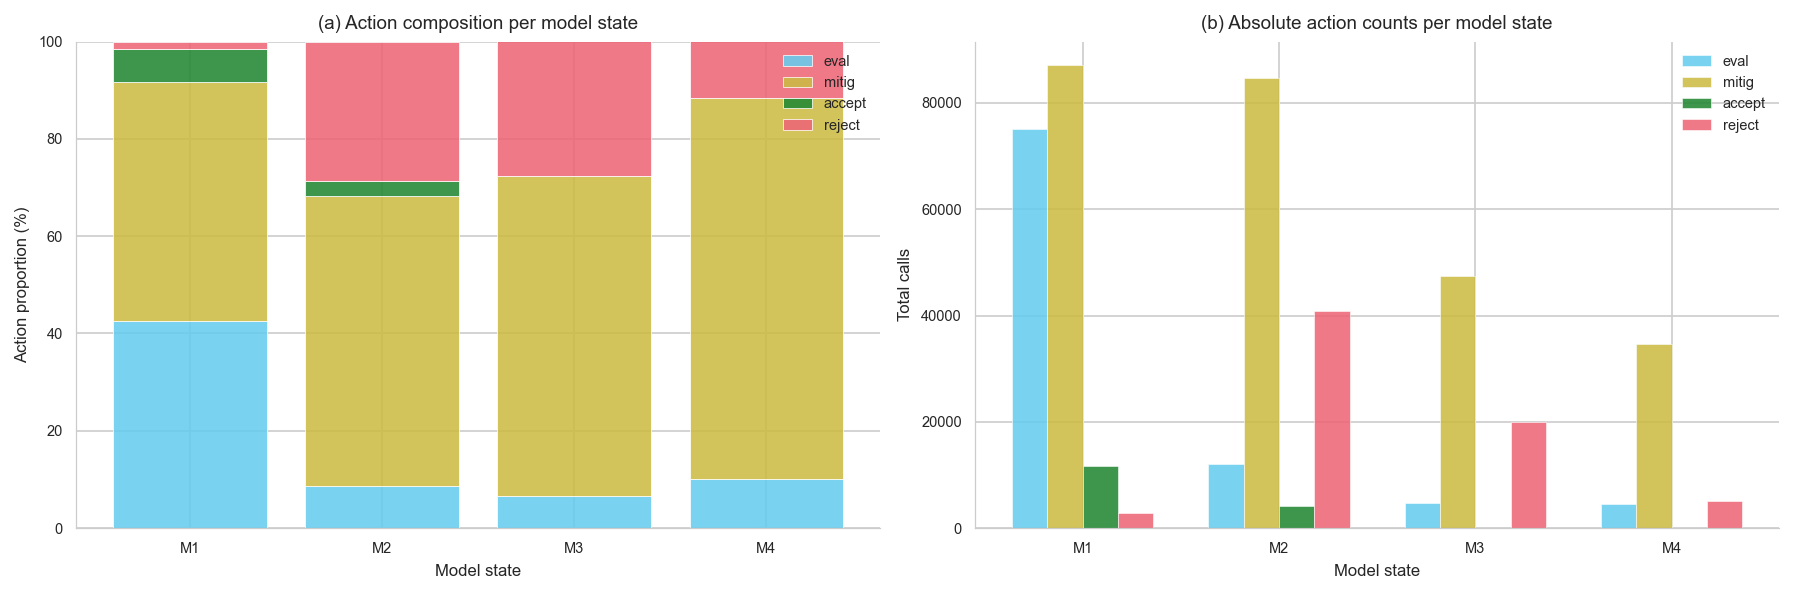

In [151]:
# ─── 4.1 Action Distribution per Model ───────────────────────────────────────
def extract_model_action_pairs(path):
    nodes = [n.strip() for n in path.split('->')]
    pairs = []
    for i, node in enumerate(nodes):
        if node.startswith('a_') and i > 0 and nodes[i-1] in ['M1','M2','M3','M4']:
            pairs.append((nodes[i-1], node))
    return pairs

all_pairs = []
for path in df['action_path']:
    all_pairs.extend(extract_model_action_pairs(path))

action_list = ['a_eval','a_mitig','a_accept','a_reject']
ma_counts = defaultdict(Counter)
for m, a in all_pairs:
    ma_counts[m][a] += 1

ma_pct = pd.DataFrame(
    {m: {a: ma_counts[m].get(a,0)/max(sum(ma_counts[m].values()),1)*100
         for a in action_list} for m in models}
).T.reindex(models)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) stacked bar
ax = axes[0]
bottom = np.zeros(len(models))
for act in action_list:
    vals = ma_pct[act].values
    ax.bar(models, vals, bottom=bottom,
           color=ACTION_COLORS[act], alpha=0.88, label=act.replace('a_',''),
           edgecolor='white', linewidth=0.4)
    bottom += vals
ax.set_xlabel('Model state')
ax.set_ylabel('Action proportion (%)')
ax.set_title('(a) Action composition per model state')
ax.legend(loc='upper right', frameon=False)
ax.set_ylim(0, 100)

# (b) grouped absolute counts
ax = axes[1]
x = np.arange(len(models))
w = 0.18
for k, act in enumerate(action_list):
    vals = [ma_counts[m].get(act, 0) for m in models]
    ax.bar(x + k*w - 1.5*w, vals, w, color=ACTION_COLORS[act],
           alpha=0.88, label=act.replace('a_',''), edgecolor='white', linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_xlabel('Model state')
ax.set_ylabel('Total calls')
ax.set_title('(b) Absolute action counts per model state')
ax.legend(frameon=False)

plt.tight_layout()
# savefig('07_action_distribution_per_model')
plt.show()

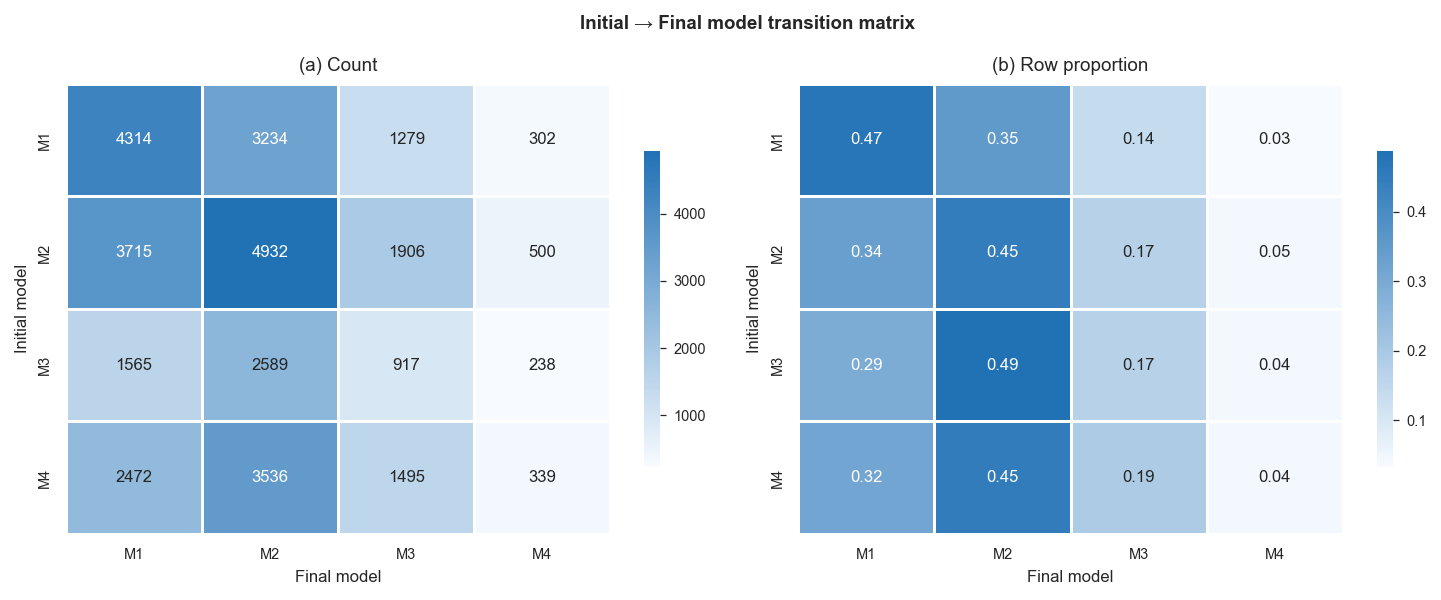

In [152]:
# ─── 2.3 Initial Model × Final Model Transition Heatmap ──────────────────────
trans_count = pd.crosstab(df['initial_model'], df['final_model']).reindex(
    index=models, columns=models, fill_value=0)
trans_pct = trans_count.div(trans_count.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
nc_seq = LinearSegmentedColormap.from_list('NC_seq', ['#F7FBFF','#2171B5'])

for ax, data, title, fmt in zip(axes,
        [trans_count, trans_pct],
        ['(a) Count', '(b) Row proportion'],
        ['d', '.2f']):
    sns.heatmap(data, ax=ax, cmap=nc_seq, annot=True, fmt=fmt,
                annot_kws={'size': 8}, linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.7})
    ax.set_title(title)
    ax.set_xlabel('Final model')
    ax.set_ylabel('Initial model')

fig.suptitle('Initial → Final model transition matrix', fontsize=9, fontweight='bold')
plt.tight_layout()
# savefig('04_model_transition_matrix')
plt.show()

In [153]:
# ─── 5.1 Build Transition Count Matrix ───────────────────────────────────────
def extract_transitions(path):
    nodes = [n.strip() for n in path.split('->')]
    trans = []
    for i in range(len(nodes)-2):
        if nodes[i+1].startswith('a_'):
            frm = nodes[i]
            act = nodes[i+1]
            to  = nodes[i+2]
            # collapse terminal labels → Accept / Reject
            to_norm  = 'Accept' if to.startswith('Accept') else ('Reject_terminal' if to.startswith('Reject') else to)
            frm_norm = frm  # keep model labels as-is
            trans.append((frm_norm, act, to_norm))
    return trans

all_trans = []
for path in df['action_path']:
    all_trans.extend(extract_transitions(path))

tc = Counter(all_trans)
print(f'Unique (state, action, next_state) triples: {len(tc)}')

# ── Transition probability matrix: P(next | current, action)
from_action_totals = defaultdict(int)
for (frm, act, to), cnt in tc.items():
    from_action_totals[(frm, act)] += cnt

trans_prob = {}
for (frm, act, to), cnt in tc.items():
    total = from_action_totals[(frm, act)]
    trans_prob[(frm, act, to)] = cnt / total

# Show top transitions
top_trans = pd.DataFrame([
    {'from': f, 'action': a, 'to': t, 'count': tc[(f,a,t)], 'prob': round(trans_prob[(f,a,t)],3)}
    for (f,a,t) in tc
]).sort_values('count', ascending=False).head(20)
print(top_trans.to_string(index=False))

Unique (state, action, next_state) triples: 85
       from   action              to  count  prob
         M1  a_mitig              M1  87189 1.000
         M2 a_reject Reject_terminal  40788 1.000
         M1   a_eval              M1  37658 0.501
         M1   a_eval              M2  37479 0.499
         M2  a_mitig              M1  28405 0.335
         M2  a_mitig              M3  28169 0.332
         M2  a_mitig              M2  28161 0.332
         M3  a_mitig              M2  23901 0.504
         M3  a_mitig              M3  23536 0.496
         M3 a_reject Reject_terminal  19972 1.000
         M4  a_mitig              M4  17362 0.501
         M4  a_mitig              M2  17299 0.499
         M1 a_accept          Accept  11723 1.000
         s0   a_next              M2  11053 0.332
         s0   a_next              M1   9129 0.274
         s0   a_next              M4   7842 0.235
Reject_M2_c   a_next              M2   5347 0.323
         s0   a_next              M3   5309 0.159
   

In [154]:
# ── 0. Imports & Style ────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import networkx as nx
from pathlib import Path

# ── Nature Communications palette ────────────────────────────────────────────
NC = {
    'blue':   '#4477AA', 'cyan':   '#66CCEE', 'green':  '#228833',
    'yellow': '#CCBB44', 'red':    '#EE6677', 'purple': '#AA3377',
    'grey':   '#BBBBBB', 'orange': '#E07030', 'teal':   '#3D8B8B',
    'navy':   '#223F5E',
}
NC_LIST = [NC[k] for k in ['blue','red','green','yellow','purple','cyan','orange','teal','grey']]
NC_DIV  = ['#4477AA','#77AADD','#BBCCEE','#F7F7F7','#FFCCCC','#EE9988','#BB4444']

MODEL_COLORS  = {'M1': NC['blue'], 'M2': NC['green'], 'M3': NC['orange'], 'M4': NC['red']}
ACTION_COLORS = {
    'a_next':   NC['blue'],   'a_eval':   NC['cyan'],
    'a_mitig':  NC['yellow'], 'a_accept': NC['green'],
    'a_reject': NC['red'],
}
TERM_COLORS   = {'Accept': NC['green'], 'Reject': NC['red']}
MODELS        = ['M1', 'M2', 'M3', 'M4']
ACTIONS       = ['a_next', 'a_eval', 'a_mitig', 'a_accept', 'a_reject']

matplotlib.rcParams.update({
    'font.family':       'Arial',
    'font.size':          8,
    'axes.titlesize':     9,
    'axes.labelsize':     8,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.6,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.major.width':  0.6,
    'ytick.major.width':  0.6,
    'xtick.major.size':   3,
    'ytick.major.size':   3,
    'lines.linewidth':    1.2,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'pdf.fonttype':       42,
})

OUT = Path('figures_transition')
OUT.mkdir(exist_ok=True)

def savefig(name):
    plt.savefig(OUT / f'{name}.pdf')
    plt.savefig(OUT / f'{name}.png', dpi=300)
    plt.show()

In [155]:
# ── 1. Load & Aggregate ───────────────────────────────────────────────────────
CSV_PATH = 'E:\\pythonProject\\cross_new\\transition_v4.csv'   # ← change if needed
raw = pd.read_csv(CSV_PATH)
print(f'Raw rows: {len(raw):,}  |  Total transitions: {raw["count"].sum():,}')
print(raw.head(5).to_string(index=False))

# Aggregate duplicate (current_model, action, next_model) rows
# The same triplet can appear multiple times with different sub-counts
agg = (
    raw.groupby(['current_model', 'action', 'next_model'], as_index=False)
       .agg(count=('count','sum'), total_from_sa=('total_from_state_action','sum'))
)

# Recompute marginal totals per (current_model, action)
sa_total = agg.groupby(['current_model','action'])['count'].sum().rename('sa_total')
agg = agg.join(sa_total, on=['current_model','action'])
agg['prob'] = agg['count'] / agg['sa_total']

# Classify next_model
agg['next_type'] = agg['next_model'].apply(
    lambda x: 'Accept' if x.startswith('Accept')
    else ('Reject' if x.startswith('Reject') else x)
)
# Collapse terminal labels → canonical Accept / Reject for aggregate views
agg['next_collapsed'] = agg['next_model'].apply(
    lambda x: 'Accept' if x.startswith('Accept')
    else ('Reject' if x.startswith('Reject') else x)
)

print(f'\nAggregated rows: {len(agg)}')
print('\nnext_type totals:')
print(agg.groupby('next_type')['count'].sum().sort_values(ascending=False).to_string())

# Aggregate further: collapse terminal labels for graph/heatmap
agg_c = (
    agg.groupby(['current_model','action','next_collapsed'], as_index=False)
       .agg(count=('count','sum'), sa_total=('sa_total','first'))
)
sa_total2 = agg_c.groupby(['current_model','action'])['count'].sum().rename('sa_total2')
agg_c = agg_c.join(sa_total2, on=['current_model','action'])
agg_c['prob'] = agg_c['count'] / agg_c['sa_total2']

agg.head()

Raw rows: 141  |  Total transitions: 519,936
                                                             current_state current_model  action                                                                      next_state next_model  count  total_from_state_action  transition_probability
             d=structured,b=none,r=false,c=EU_only,k=start,m=optimal,mt=M1            M1 a_mitig                   d=structured,b=none,r=false,c=EU_only,k=start,m=optimal,mt=M1         M1  57456                    57456                  1.0000
             d=structured,b=none,r=false,c=EU_only,k=start,m=optimal,mt=M1            M1  a_next      d=multimodal,b=remote_id,r=high-risk,c=adequacy,k=start,m=suboptimal,mt=M2         M2  27821                    84674                  0.3286
d=multimodal,b=remote_id,r=high-risk,c=adequacy,k=start,m=suboptimal,mt=M2            M2 a_mitig               d=structured,b=none,r=high-risk,c=EU_only,k=start,m=optimal,mt=M1         M1  25258                    75247    

,current_model,action,next_model,count,total_from_sa,sa_total,prob,next_type,next_collapsed
0,M1,a_accept,Accept_M1_a,8074,11723,11723,0.688732,Accept,Accept
1,M1,a_accept,Accept_M1_b,3546,11723,11723,0.302482,Accept,Accept
2,M1,a_accept,Accept_M1_c,97,11723,11723,0.008274,Accept,Accept
3,M1,a_accept,Accept_M1_d,6,10260,11723,0.000512,Accept,Accept
4,M1,a_eval,M1,37658,100239,75137,0.501191,M1,M1


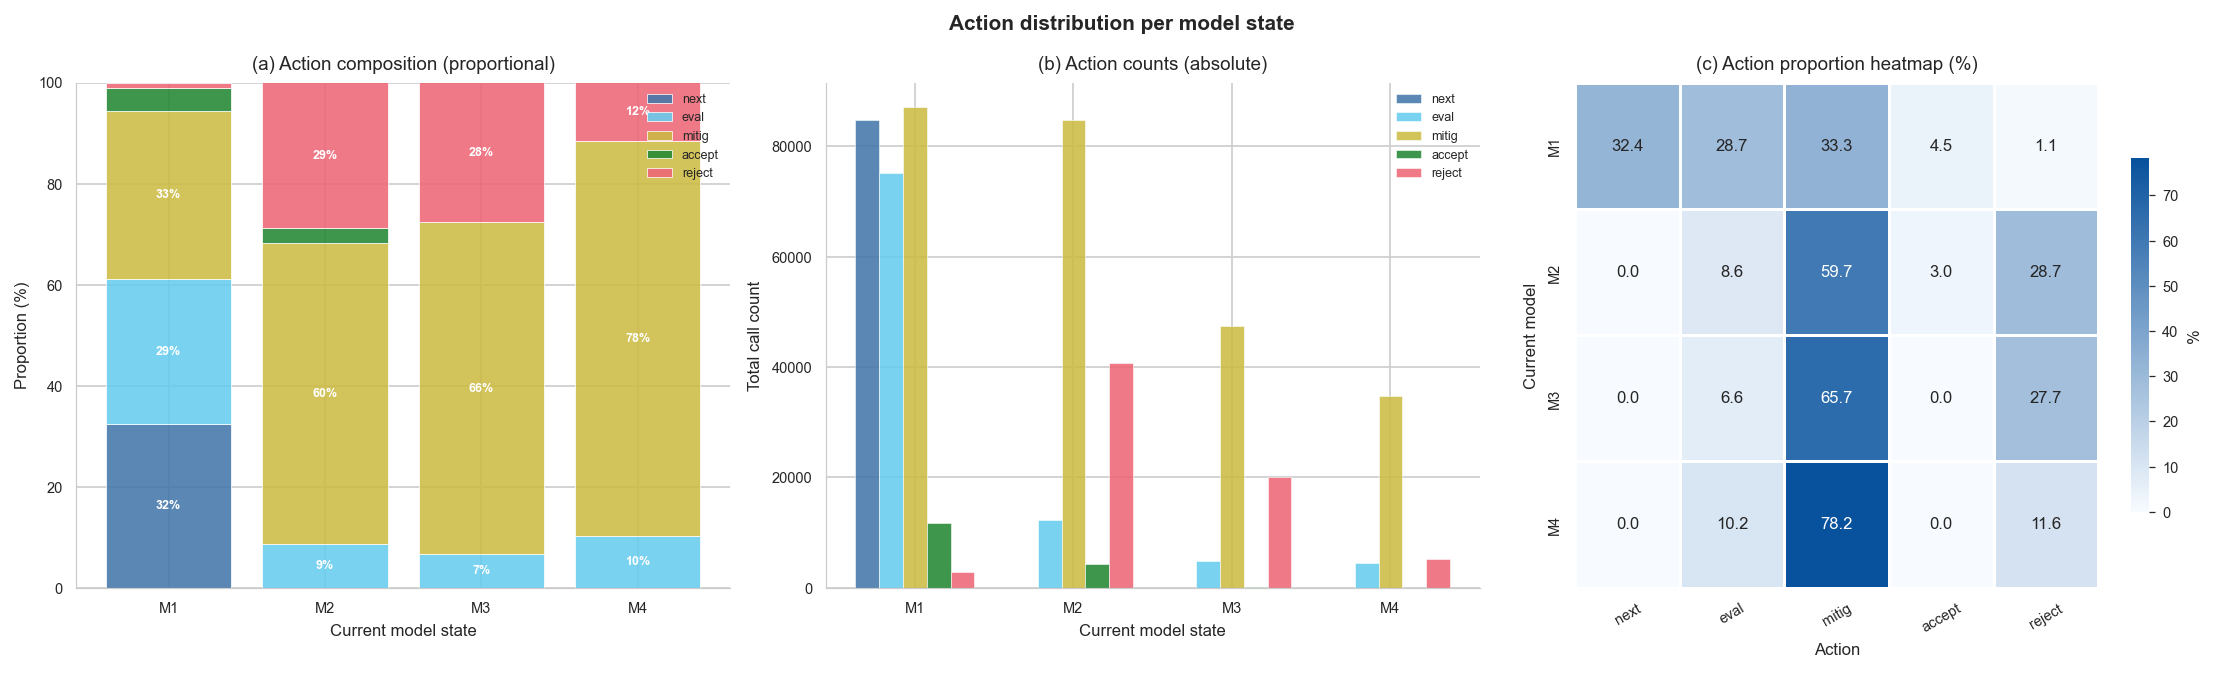

In [156]:
# ── 1.1  Total calls per (model, action) ──────────────────────────────────────
ma_counts = agg.groupby(['current_model','action'])['count'].sum().unstack(fill_value=0)
# ensure all actions present
for a in ACTIONS:
    if a not in ma_counts.columns:
        ma_counts[a] = 0
ma_counts = ma_counts[ACTIONS].reindex(MODELS)

ma_pct = ma_counts.div(ma_counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Action distribution per model state', fontsize=10, fontweight='bold')

# (a) Stacked bar — proportion
ax = axes[0]
bottom = np.zeros(len(MODELS))
for act in ACTIONS:
    vals = ma_pct[act].values
    bars = ax.bar(MODELS, vals, bottom=bottom,
                  color=ACTION_COLORS[act], alpha=0.88,
                  label=act.replace('a_',''), edgecolor='white', linewidth=0.4)
    # label inside segment if > 5%
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=6, color='white', fontweight='bold')
    bottom += vals
ax.set_ylim(0, 100)
ax.set_ylabel('Proportion (%)')
ax.set_xlabel('Current model state')
ax.set_title('(a) Action composition (proportional)')
ax.legend(loc='upper right', frameon=False, fontsize=6)

# (b) Grouped bar — absolute count
ax = axes[1]
x  = np.arange(len(MODELS))
w  = 0.15
for k, act in enumerate(ACTIONS):
    ax.bar(x + (k - 2)*w, ma_counts[act].values, w,
           color=ACTION_COLORS[act], alpha=0.88,
           label=act.replace('a_',''), edgecolor='white', linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(MODELS)
ax.set_ylabel('Total call count')
ax.set_xlabel('Current model state')
ax.set_title('(b) Action counts (absolute)')
ax.legend(frameon=False, fontsize=6)

# (c) Heatmap
ax = axes[2]
nc_seq = LinearSegmentedColormap.from_list('seq', ['#F7FBFF','#08519C'])
sns.heatmap(ma_pct, ax=ax, cmap=nc_seq, annot=True, fmt='.1f',
            annot_kws={'size':8}, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink':0.7, 'label':'%'})
ax.set_title('(c) Action proportion heatmap (%)')
ax.set_xlabel('Action')
ax.set_ylabel('Current model')
ax.set_xticklabels([a.replace('a_','') for a in ACTIONS], rotation=30)

plt.tight_layout()
# savefig('T01_action_distribution')

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


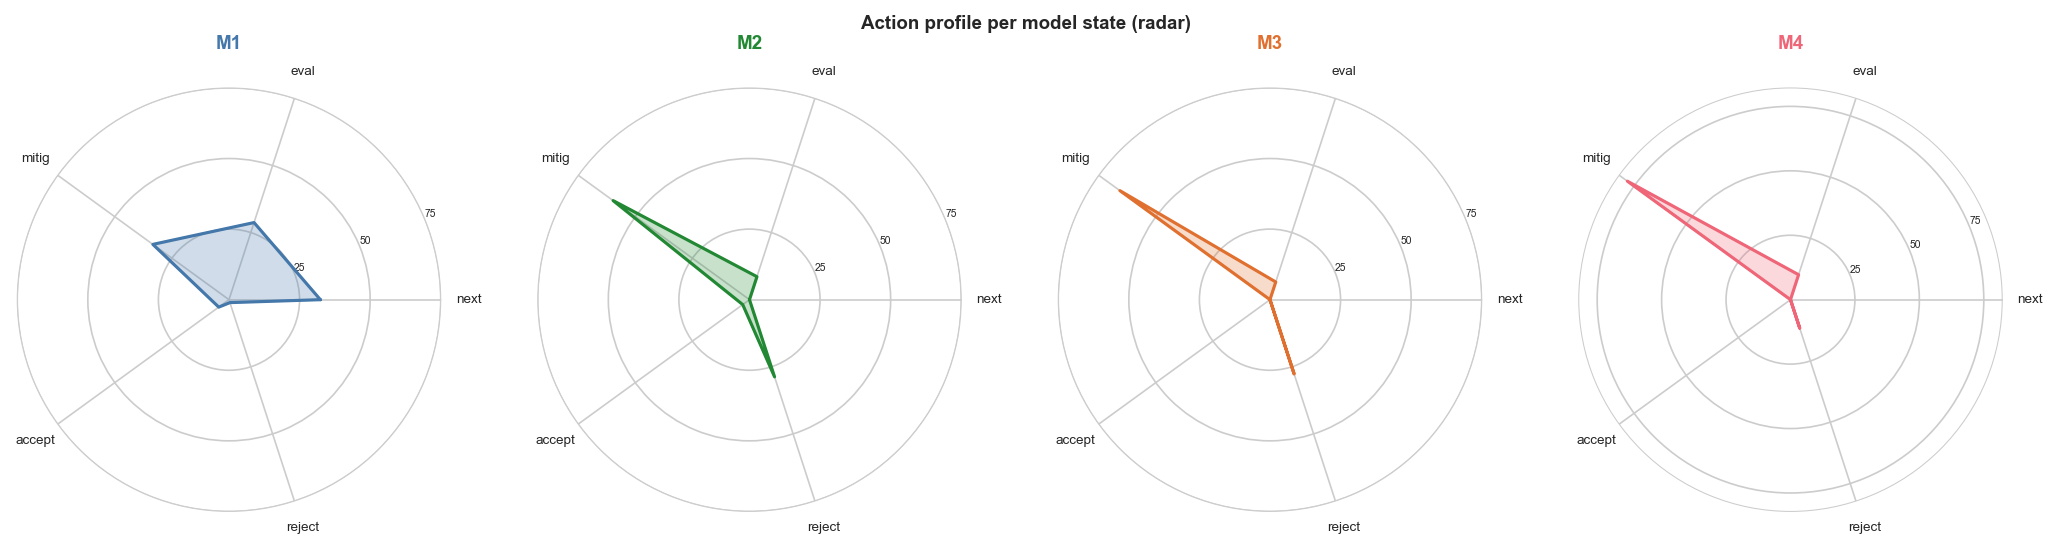

In [157]:
# ── 1.2  Per-model action share — polar / radar chart ──────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), subplot_kw={'projection':'polar'})
fig.suptitle('Action profile per model state (radar)', fontsize=9, fontweight='bold')

N      = len(ACTIONS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close polygon

for ax, m in zip(axes, MODELS):
    vals = ma_pct.loc[m, ACTIONS].values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=MODEL_COLORS[m], lw=1.5)
    ax.fill(angles, vals, color=MODEL_COLORS[m], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([a.replace('a_','') for a in ACTIONS], fontsize=6.5)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(['25','50','75'], fontsize=5)
    ax.set_title(m, color=MODEL_COLORS[m], fontsize=9, fontweight='bold', pad=8)
    ax.spines['polar'].set_linewidth(0.5)

plt.tight_layout()
savefig('T02_action_radar')

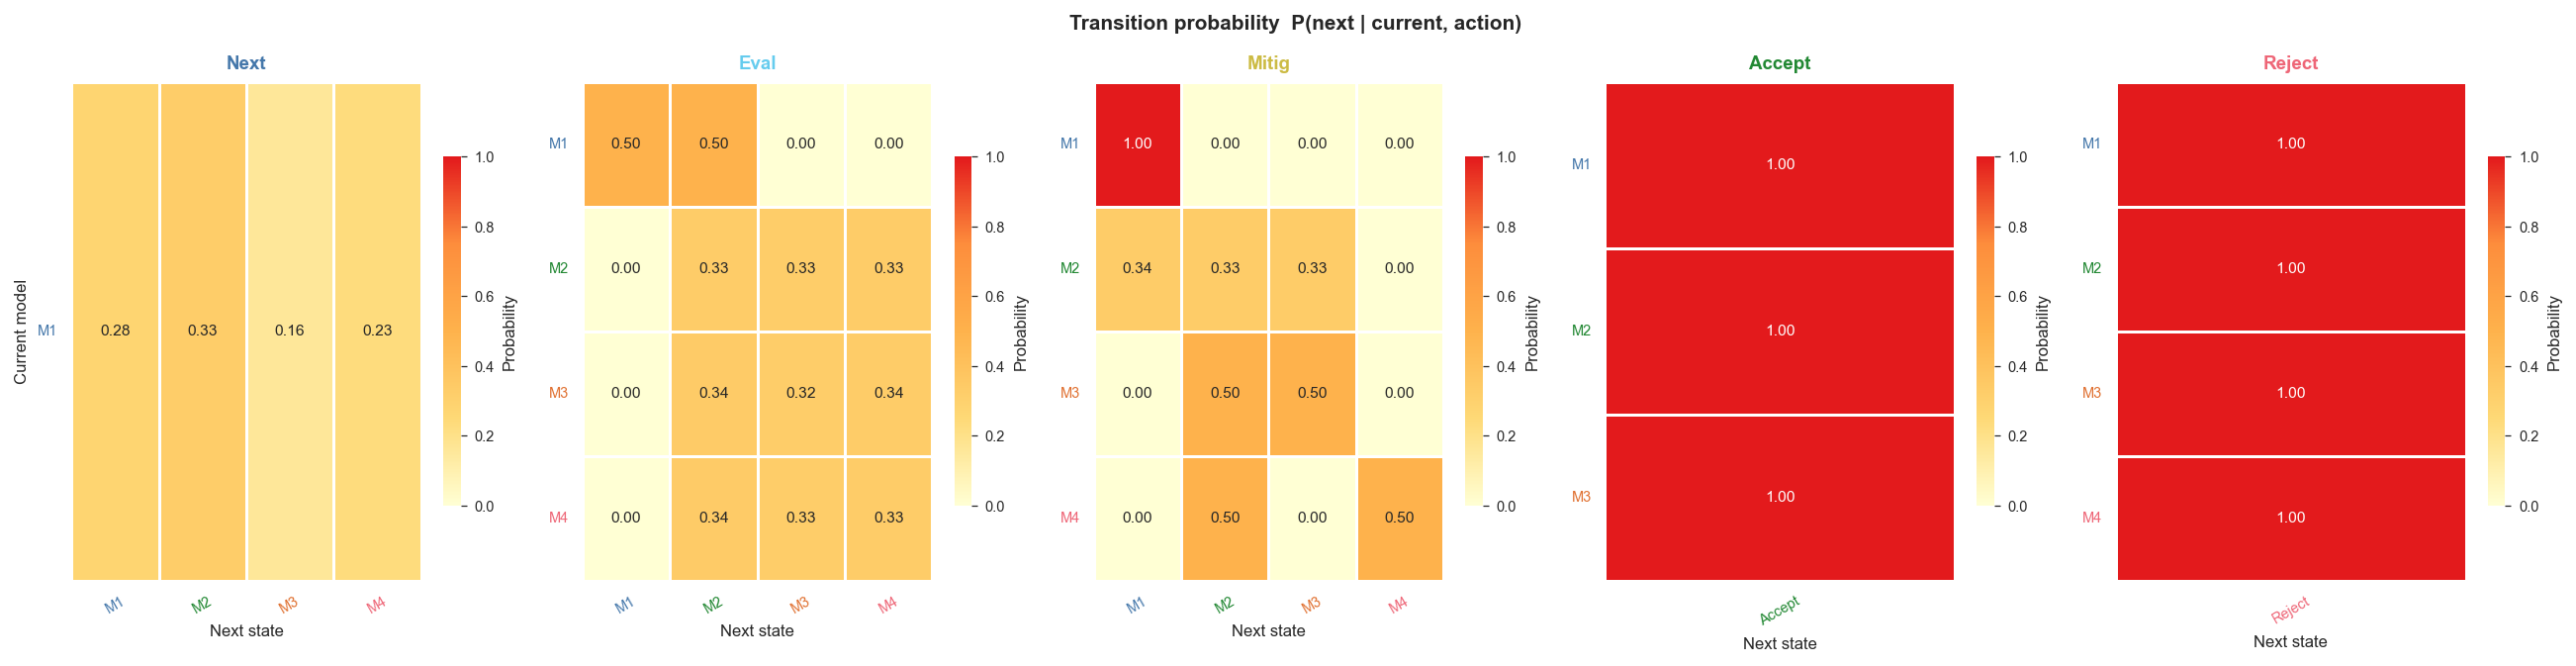

In [158]:
# ── 2.1  P(next | current, action) heatmap — one subplot per action ──────────
all_next = sorted(agg_c['next_collapsed'].unique())
# Order: models first, then terminals
next_order = [n for n in MODELS if n in all_next] + \
             [n for n in ['Accept','Reject'] if n in all_next]

relevant_actions = [a for a in ACTIONS
                    if a in agg_c['action'].unique()]

fig, axes = plt.subplots(1, len(relevant_actions),
                          figsize=(3.5 * len(relevant_actions), 4.5))
fig.suptitle('Transition probability  P(next | current, action)',
             fontsize=10, fontweight='bold')

if len(relevant_actions) == 1:
    axes = [axes]

nc_yr = LinearSegmentedColormap.from_list('yr', ['#FFFFD4','#FED976','#FEB24C','#FD8D3C','#E31A1C'])

for ax, act in zip(axes, relevant_actions):
    sub  = agg_c[agg_c['action'] == act]
    frm  = [m for m in MODELS if m in sub['current_model'].values]
    to   = [n for n in next_order if n in sub['next_collapsed'].values]
    if not frm or not to:
        ax.axis('off'); continue

    mat  = pd.DataFrame(0.0, index=frm, columns=to)
    for _, row in sub.iterrows():
        if row['current_model'] in frm and row['next_collapsed'] in to:
            mat.loc[row['current_model'], row['next_collapsed']] += row['prob']
    # row-normalise (prob sum may deviate slightly after aggregation)
    mat = mat.div(mat.sum(axis=1).replace(0, 1), axis=0)

    sns.heatmap(mat, ax=ax, cmap=nc_yr, vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 7.5},
                linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.7, 'label': 'Probability'})

    # colour-code column labels by type
    for label in ax.get_xticklabels():
        t = label.get_text()
        if t in MODEL_COLORS:
            label.set_color(MODEL_COLORS[t])
        elif t == 'Accept':
            label.set_color(NC['green'])
        elif t == 'Reject':
            label.set_color(NC['red'])

    for label in ax.get_yticklabels():
        label.set_color(MODEL_COLORS.get(label.get_text(), '#333'))

    ax.set_title(act.replace('a_','').capitalize(), fontsize=9,
                 color=ACTION_COLORS[act], fontweight='bold')
    ax.set_xlabel('Next state')
    ax.set_ylabel('Current model' if act == relevant_actions[0] else '')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()
# savefig('T03_transition_heatmaps')

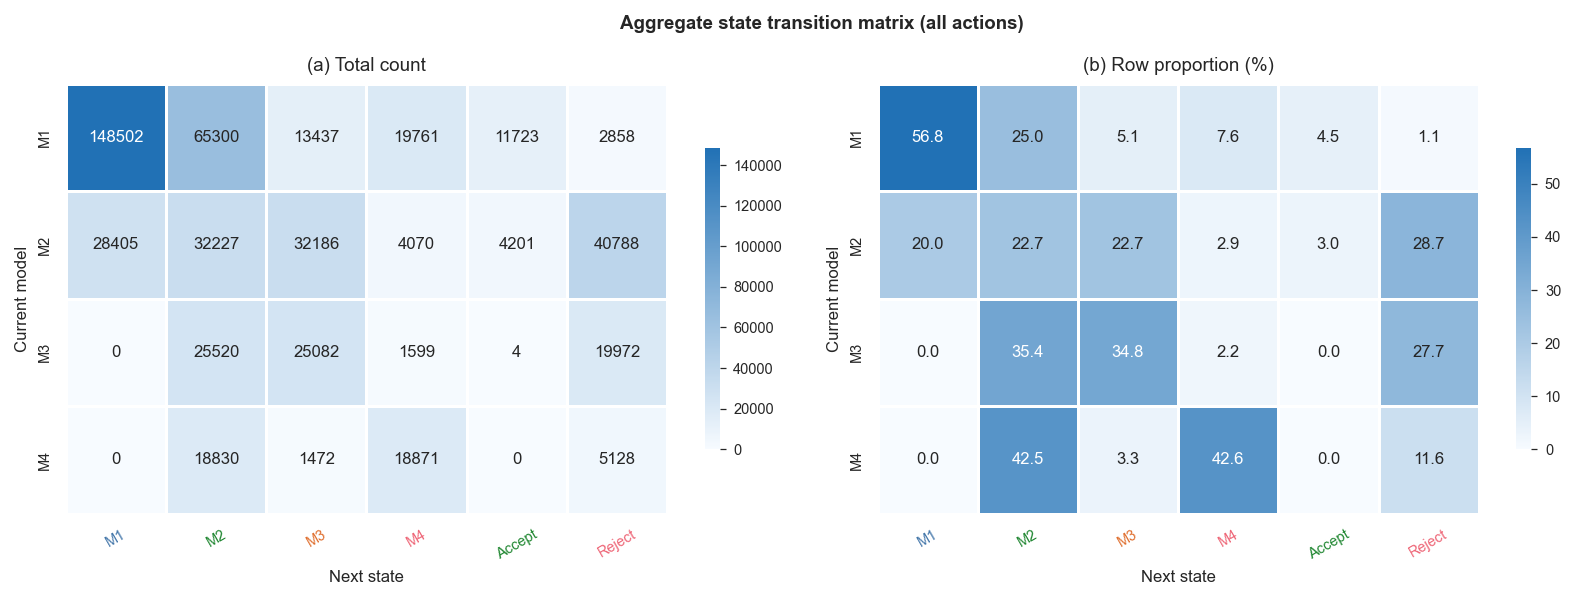

In [159]:
# ── 2.2  Aggregate transition matrix — all actions combined ───────────────────
total_flow = (
    agg_c.groupby(['current_model','next_collapsed'])['count']
         .sum()
         .unstack(fill_value=0)
         .reindex(index=MODELS, columns=next_order, fill_value=0)
)
flow_pct = total_flow.div(total_flow.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Aggregate state transition matrix (all actions)', fontsize=9, fontweight='bold')

nc_blues = LinearSegmentedColormap.from_list('blues', ['#F7FBFF','#2171B5'])

for ax, data, title, fmt in [
    (axes[0], total_flow, '(a) Total count',       'd'),
    (axes[1], flow_pct,   '(b) Row proportion (%)', '.1f'),
]:
    sns.heatmap(data, ax=ax, cmap=nc_blues,
                annot=True, fmt=fmt, annot_kws={'size': 8},
                linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.7})
    ax.set_title(title)
    ax.set_xlabel('Next state')
    ax.set_ylabel('Current model')
    ax.tick_params(axis='x', rotation=30)

    for label in ax.get_xticklabels():
        t = label.get_text()
        label.set_color(
            MODEL_COLORS.get(t, NC['green'] if t=='Accept' else NC['red'] if t=='Reject' else '#333'))

plt.tight_layout()
plt.show()
# savefig('T04_aggregate_transition_matrix')

Nodes: 6  Edges: 18
Nodes: ['Accept', 'M1', 'M2', 'M3', 'M4', 'Reject']


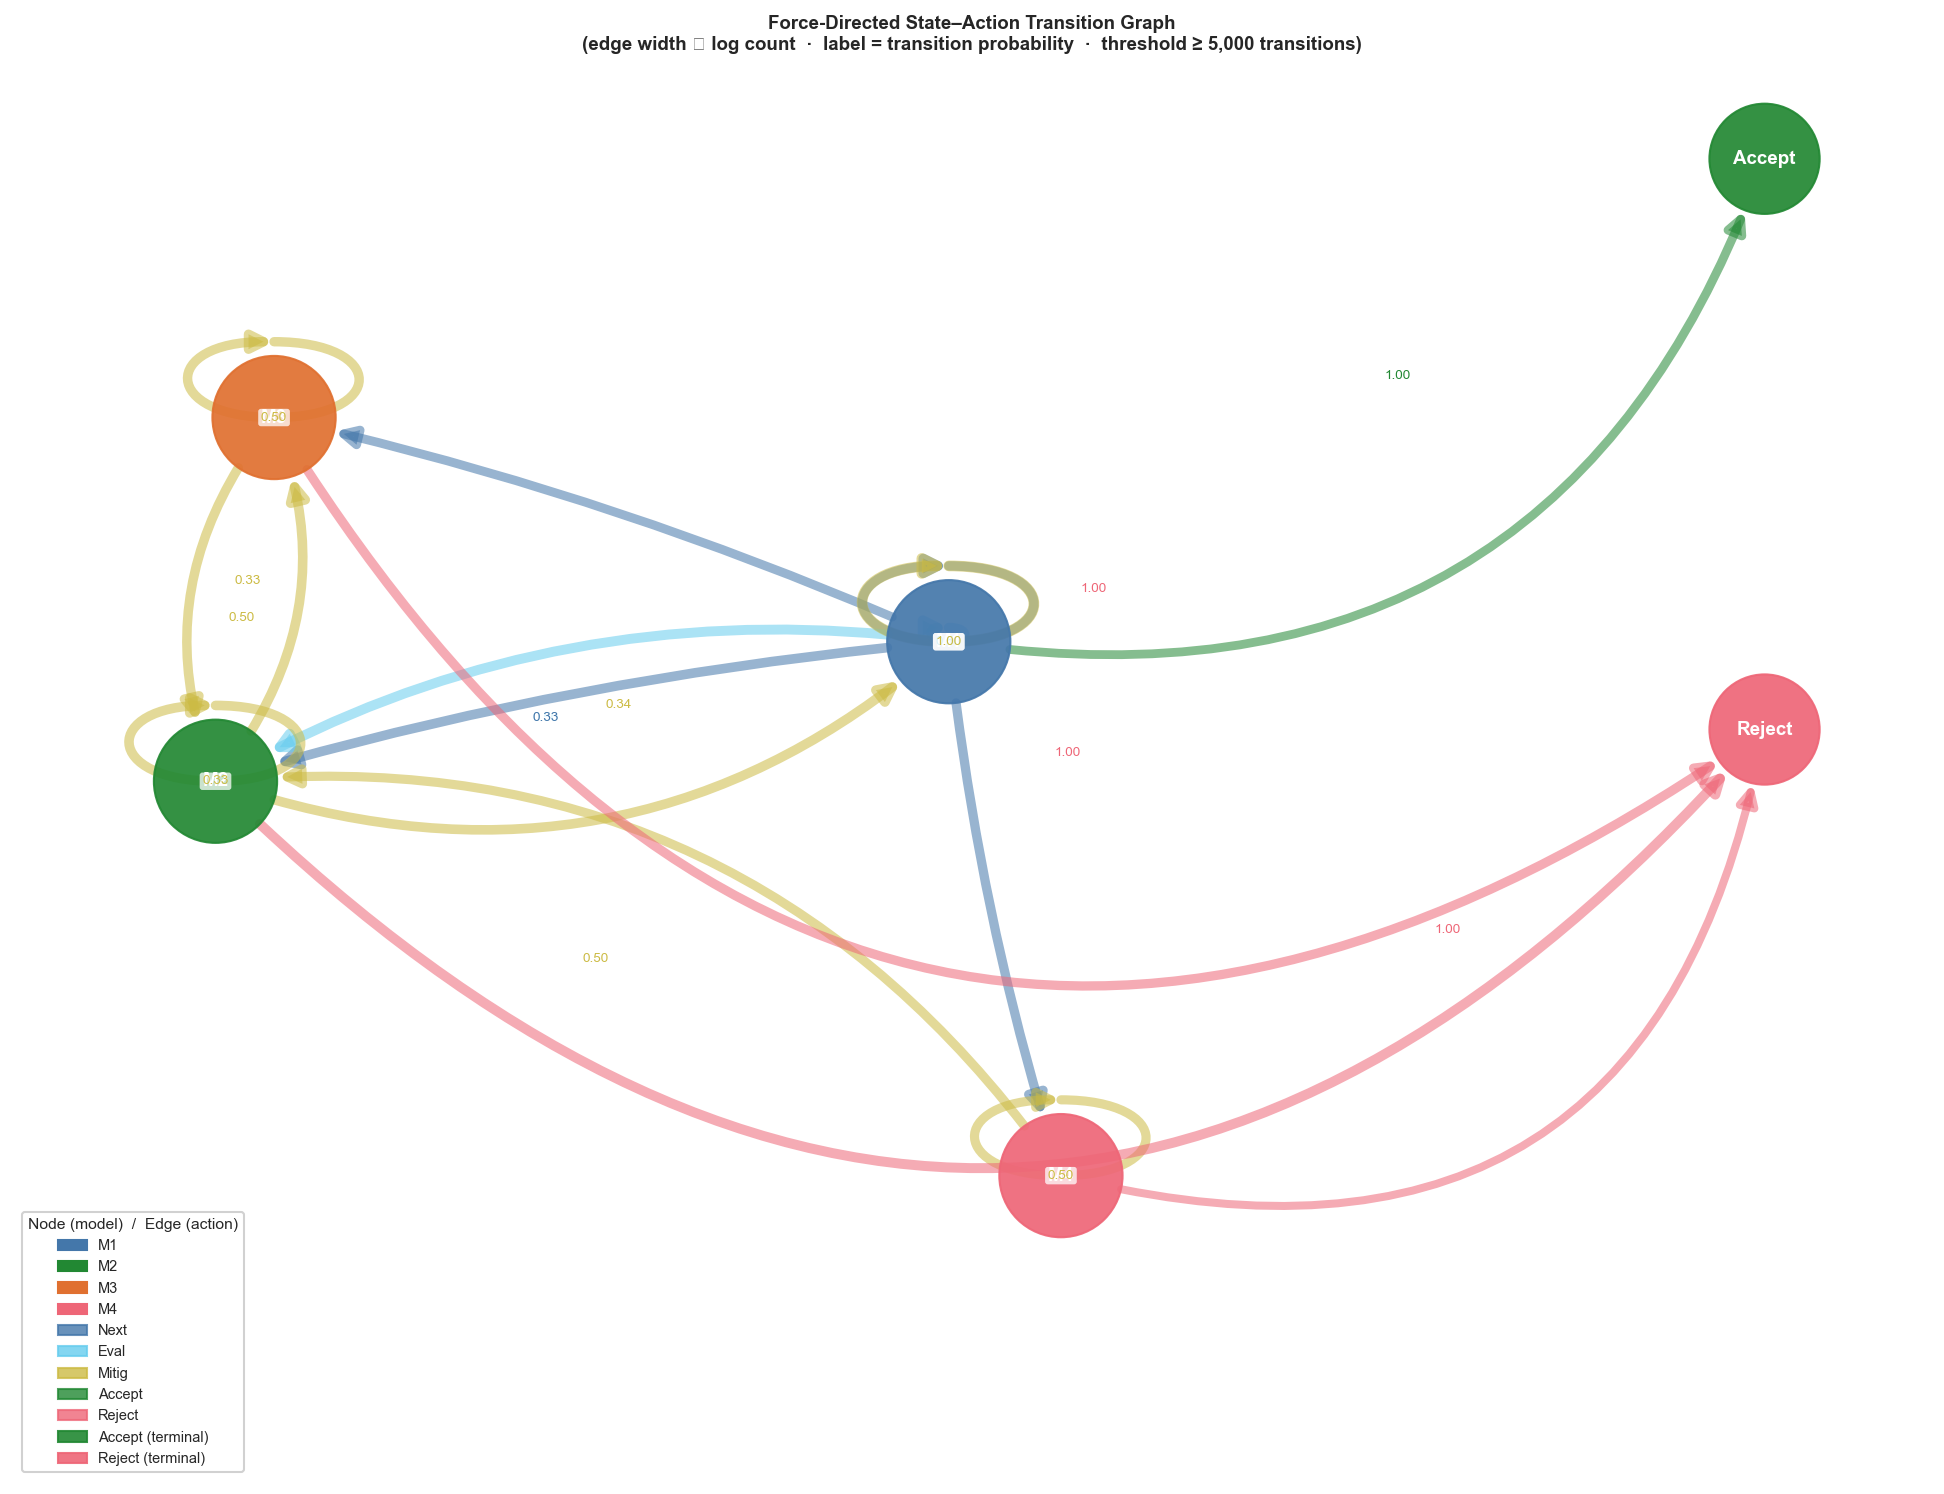

In [160]:
# ── 3.1  Build graph ──────────────────────────────────────────────────────────
MIN_COUNT = 5000   # filter low-frequency edges for clarity

G = nx.MultiDiGraph()

# node types
NODE_TYPE = {m: 'model' for m in MODELS}
NODE_TYPE.update({'Accept': 'terminal_accept', 'Reject': 'terminal_reject'})

for _, row in agg_c.iterrows():
    frm, act, to = row['current_model'], row['action'], row['next_collapsed']
    cnt, prob    = row['count'], row['prob']
    if cnt < MIN_COUNT:
        continue
    G.add_node(frm)
    G.add_node(to)
    G.add_edge(frm, to, action=act, count=int(cnt), prob=float(prob),
               weight=np.log1p(cnt))

print(f'Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}')
print('Nodes:', sorted(G.nodes()))

# ── 3.2  Layout ───────────────────────────────────────────────────────────────
# Fix terminal positions; spring-layout for model nodes
fixed_pos = {}
if 'Accept'  in G.nodes(): fixed_pos['Accept']  = ( 2.0,  1.0)
if 'Reject'  in G.nodes(): fixed_pos['Reject']  = ( 2.0, -1.0)

pos = nx.spring_layout(G, seed=42, k=2.8, iterations=200,
                        pos=fixed_pos if fixed_pos else None,
                        fixed=list(fixed_pos.keys()) if fixed_pos else None)

# ── 3.3  Draw ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
ax.set_facecolor('#FAFAFA')
ax.axis('off')

# node colour & size
node_col  = []
node_size = []
for n in G.nodes():
    nt = NODE_TYPE.get(n, 'model')
    if nt == 'model':
        node_col.append(MODEL_COLORS.get(n, NC['grey']))
        node_size.append(3500)
    elif nt == 'terminal_accept':
        node_col.append(NC['green'])
        node_size.append(2800)
    else:
        node_col.append(NC['red'])
        node_size.append(2800)

nx.draw_networkx_nodes(G, pos, ax=ax,
                        node_color=node_col, node_size=node_size, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                         font_weight='bold', font_color='white')

# draw edges grouped by action (so colour is consistent per action type)
edge_by_action = {a: [] for a in ACTIONS}
edge_widths    = {a: [] for a in ACTIONS}
edge_probs     = {a: [] for a in ACTIONS}

for u, v, data in G.edges(data=True):
    act = data['action']
    edge_by_action[act].append((u, v))
    edge_widths[act].append(data['weight'] * 0.45)
    edge_probs[act].append(data['prob'])

rad_map = {a: 0.05 + i * 0.12 for i, a in enumerate(ACTIONS)}

for act in ACTIONS:
    elist = edge_by_action[act]
    if not elist:
        continue
    nx.draw_networkx_edges(
        G, pos, edgelist=elist, ax=ax,
        edge_color=ACTION_COLORS[act],
        width=edge_widths[act],
        alpha=0.55,
        arrows=True, arrowsize=18,
        connectionstyle=f'arc3,rad={rad_map[act]}',
        node_size=node_size,
    )

# probability labels on high-confidence edges (prob > 0.3)
for u, v, data in G.edges(data=True):
    if data['prob'] > 0.30:
        mx  = (pos[u][0]*0.45 + pos[v][0]*0.55)
        my  = (pos[u][1]*0.45 + pos[v][1]*0.55)
        ax.text(mx, my, f"{data['prob']:.2f}",
                fontsize=6.5, ha='center', va='center',
                color=ACTION_COLORS[data['action']],
                bbox={'boxstyle':'round,pad=0.2','fc':'white','alpha':0.75,'ec':'none'})

# legend — actions
legend_patches = [mpatches.Patch(color=c, label=a.replace('a_','').capitalize(), alpha=0.8)
                  for a, c in ACTION_COLORS.items() if edge_by_action[a]]
legend_patches += [
    mpatches.Patch(color=NC['green'], label='Accept (terminal)', alpha=0.9),
    mpatches.Patch(color=NC['red'],   label='Reject (terminal)', alpha=0.9),
]
ax.legend(handles=legend_patches, title='Action / Node type',
          loc='lower left', frameon=True, fontsize=7,
          title_fontsize=7.5, framealpha=0.9)

# model colour legend
model_patches = [mpatches.Patch(color=c, label=m) for m,c in MODEL_COLORS.items()]
ax.legend(handles=model_patches + legend_patches[:len(legend_patches)],
          title='Node (model)  /  Edge (action)',
          loc='lower left', frameon=True, fontsize=7,
          title_fontsize=7.5, framealpha=0.9)

ax.set_title(
    f'Force-Directed State–Action Transition Graph\n'
    f'(edge width ∝ log count  ·  label = transition probability  ·  '
    f'threshold ≥ {MIN_COUNT:,} transitions)',
    fontsize=9, fontweight='bold', pad=10
)
plt.tight_layout()
plt.show()
# savefig('T05_force_directed_graph')

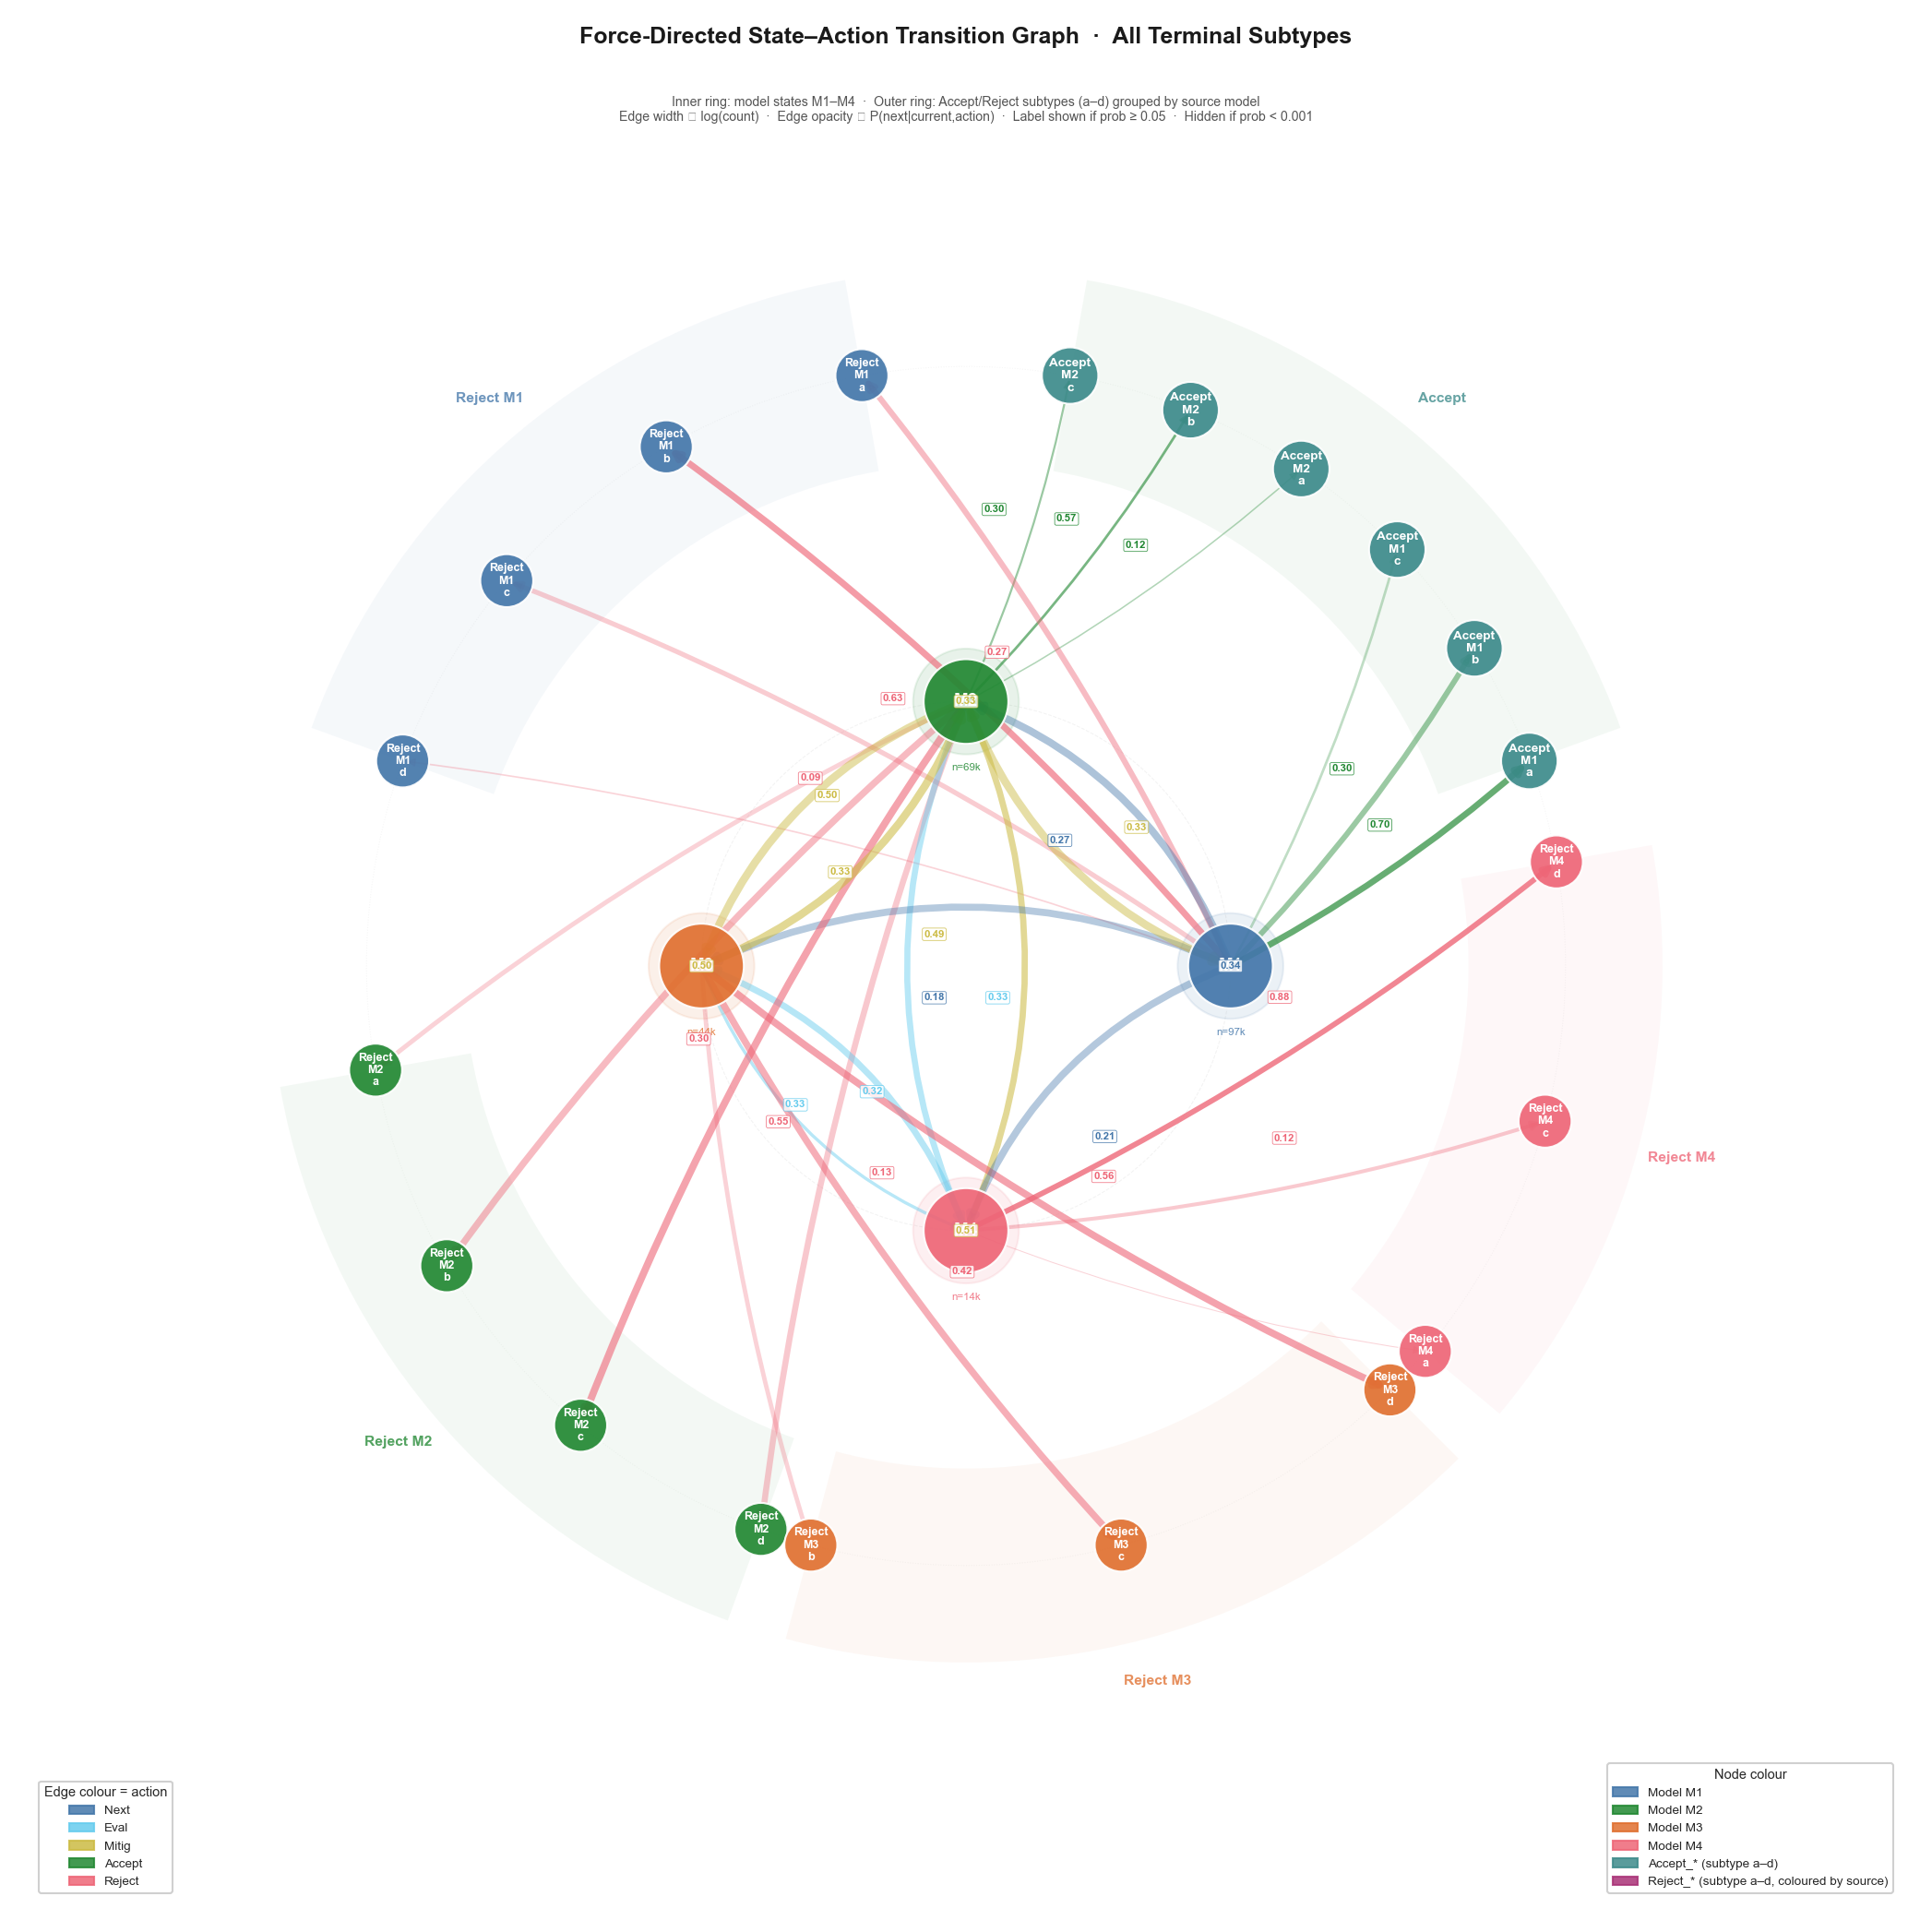

In [161]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import networkx as nx

# ── Nature Communications palette ─────────────────────────────────────────────
NC = {
    'blue':   '#4477AA', 'cyan':   '#66CCEE', 'green':  '#228833',
    'yellow': '#CCBB44', 'red':    '#EE6677', 'purple': '#AA3377',
    'grey':   '#BBBBBB', 'orange': '#E07030', 'teal':   '#3D8B8B',
    'navy':   '#223F5E',
}

MODEL_COLORS = {
    'M1': NC['blue'], 'M2': NC['green'],
    'M3': NC['orange'], 'M4': NC['red'],
}
ACTION_COLORS = {
    'a_next':   NC['blue'],   'a_eval':   NC['cyan'],
    'a_mitig':  NC['yellow'], 'a_accept': NC['green'],
    'a_reject': NC['red'],
}

matplotlib.rcParams.update({
    'font.family':  'Arial', 'font.size': 8,
    'figure.dpi':   150,     'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'pdf.fonttype': 42,
})

# ── Load & aggregate same triplets (ALL subtype nodes preserved) ──────────────
df = pd.read_csv("E:\\pythonProject\\cross_new\\transition_v6.csv")

agg = (df.groupby(['current_model', 'action', 'next_model'], as_index=False)
         .agg(count=('count', 'sum')))
sa  = agg.groupby(['current_model', 'action'])['count'].sum().rename('sa_total')
agg = agg.join(sa, on=['current_model', 'action'])
agg['prob'] = agg['count'] / agg['sa_total']

# ── Build graph ───────────────────────────────────────────────────────────────
MIN_PROB = 0.001

G = nx.DiGraph()
for _, row in agg.iterrows():
    frm, act, to = row['current_model'], row['action'], row['next_model']
    prob, cnt    = row['prob'], row['count']
    if prob < MIN_PROB:
        continue
    G.add_node(frm)
    G.add_node(to)
    G.add_edge(frm, to, action=act, prob=float(prob),
               count=int(cnt), weight=float(np.log1p(cnt)))

MODELS        = ['M1', 'M2', 'M3', 'M4']
accept_nodes  = sorted([n for n in G.nodes() if n.startswith('Accept')])
reject_nodes  = sorted([n for n in G.nodes() if n.startswith('Reject')])

# ── Layout: inner ring (models) + outer ring (terminal subtypes) ──────────────
pos = {}

# Inner ring — model nodes at radius 1.5, 90° apart
inner_r = 1.5
for m, ang_deg in zip(MODELS, [0, 90, 180, 270]):
    rad = np.deg2rad(ang_deg)
    pos[m] = np.array([inner_r * np.cos(rad), inner_r * np.sin(rad)])

# Outer ring — terminals grouped in fan sectors by source model
outer_r = 3.4
sector_config = {
    'Accept':   (20,  80,  accept_nodes),
    'Reject_M1':(100, 160, [n for n in reject_nodes if '_M1_' in n]),
    'Reject_M2':(190, 250, [n for n in reject_nodes if '_M2_' in n]),
    'Reject_M3':(255, 315, [n for n in reject_nodes if '_M3_' in n]),
    'Reject_M4':(320, 370, [n for n in reject_nodes if '_M4_' in n]),
}
for _, (a_start, a_end, nodes) in sector_config.items():
    if not nodes:
        continue
    angles = np.linspace(a_start, a_end, len(nodes))
    for n, ang in zip(nodes, angles):
        pos[n] = np.array([outer_r * np.cos(np.deg2rad(ang)),
                            outer_r * np.sin(np.deg2rad(ang))])

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 14))
ax.set_facecolor('#FAFAFA')
ax.axis('off')

# Subtle guide rings
for r, ls, a in [(inner_r, '--', 0.10), (outer_r, ':', 0.08)]:
    ax.add_patch(plt.Circle((0, 0), r, fill=False, ec='#888',
                              lw=0.5, ls=ls, alpha=a, zorder=0))

# Background glow for model nodes
for m in MODELS:
    x, y = pos[m]
    ax.add_patch(plt.Circle((x, y), 0.30, color=MODEL_COLORS[m],
                              alpha=0.10, zorder=0))

# Soft sector shading for terminal groups
sector_colors = {
    'Accept':    NC['green'],
    'Reject_M1': NC['blue'],
    'Reject_M2': NC['green'],
    'Reject_M3': NC['orange'],
    'Reject_M4': NC['red'],
}
for key, (a0, a1, _) in sector_config.items():
    ax.add_patch(Wedge((0, 0), outer_r + 0.55, a0, a1, width=1.1,
                        facecolor=sector_colors[key], alpha=0.05, zorder=0))

# ─ edges ──────────────────────────────────────────────────────────────────────
labeled = set()
for u, v, data in sorted(G.edges(data=True), key=lambda e: e[2]['count']):
    act  = data['action']
    prob = data['prob']
    col  = ACTION_COLORS.get(act, NC['grey'])
    lw   = max(0.5, data['weight'] * 0.42)
    alpha = 0.28 + prob * 0.58
    rad   = 0.22 if (u in MODELS and v in MODELS) else 0.06

    ax.annotate(
        "", xy=pos[v], xytext=pos[u],
        arrowprops=dict(
            arrowstyle="-|>", color=col, lw=lw, alpha=alpha,
            connectionstyle=f"arc3,rad={rad}", mutation_scale=9,
        ),
        zorder=2,
    )

    # probability label on edges prob >= 0.05, one per (u,v,action)
    if prob >= 0.05 and (u, v, act) not in labeled:
        labeled.add((u, v, act))
        pu, pv = np.array(pos[u]), np.array(pos[v])
        mid    = pu * 0.44 + pv * 0.56
        diff   = pv - pu
        norm   = np.linalg.norm(diff)
        if norm > 1e-6:
            perp = np.array([-diff[1], diff[0]]) / norm
            mid  = mid + perp * 0.18 * np.sign(rad if rad != 0 else 1)
        ax.text(mid[0], mid[1], f"{prob:.2f}",
                fontsize=5.5, ha='center', va='center',
                color=col, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='white',
                          ec=col, lw=0.4, alpha=0.82),
                zorder=5)

# ─ nodes ──────────────────────────────────────────────────────────────────────
for n in G.nodes():
    if n not in pos:
        continue
    x, y = pos[n]

    if n in MODELS:
        r, fc, fs, fw = 0.24, MODEL_COLORS[n], 9, 'bold'
    elif n.startswith('Accept'):
        r, fc, fs, fw = 0.16, NC['teal'], 6.5, 'bold'
    else:                                       # Reject subtype
        src = n.split('_')[1]                   # M1/M2/M3/M4
        r, fc, fs, fw = 0.15, MODEL_COLORS.get(src, NC['purple']), 6, 'bold'

    ax.add_patch(plt.Circle((x, y), r, color=fc, ec='white',
                              lw=1.0, zorder=3, alpha=0.92))
    label = n if n in MODELS else n.replace('_', '\n')
    ax.text(x, y, label, fontsize=fs, fontweight=fw,
            ha='center', va='center', color='white',
            zorder=4, linespacing=1.15)

    # total-count badge under model nodes
    if n in MODELS:
        total = agg[agg['current_model'] == n]['count'].sum()
        ax.text(x, y - r - 0.11, f"n={total/1000:.0f}k",
                fontsize=5.5, ha='center', va='top',
                color=MODEL_COLORS[n], alpha=0.85, zorder=4)

# ─ sector labels ──────────────────────────────────────────────────────────────
sector_label_cfg = {
    'Accept':    (outer_r + 0.80, 50,  NC['teal']),
    'Reject M1': (outer_r + 0.80, 130, NC['blue']),
    'Reject M2': (outer_r + 0.80, 220, NC['green']),
    'Reject M3': (outer_r + 0.80, 285, NC['orange']),
    'Reject M4': (outer_r + 0.80, 345, NC['red']),
}
for label, (r_l, ang_l, col) in sector_label_cfg.items():
    rad = np.deg2rad(ang_l)
    ax.text(r_l * np.cos(rad), r_l * np.sin(rad), label,
            fontsize=7.5, ha='center', va='center',
            fontweight='bold', color=col, alpha=0.78, zorder=4)

# ─ legend ─────────────────────────────────────────────────────────────────────
act_in_graph = {d['action'] for _, _, d in G.edges(data=True)}
act_patches = [mpatches.Patch(color=ACTION_COLORS[a], alpha=0.85,
                               label=a.replace('a_', '').capitalize())
               for a in ACTION_COLORS if a in act_in_graph]

node_patches = (
    [mpatches.Patch(color=MODEL_COLORS[m], alpha=0.85, label=f'Model {m}')
     for m in MODELS] +
    [mpatches.Patch(color=NC['teal'],   alpha=0.85, label='Accept_* (subtype a–d)'),
     mpatches.Patch(color=NC['purple'], alpha=0.85, label='Reject_* (subtype a–d, coloured by source)')]
)

leg1 = ax.legend(handles=act_patches, title='Edge colour = action',
                  title_fontsize=7, loc='lower left', frameon=True,
                  fontsize=6.5, framealpha=0.92, bbox_to_anchor=(0.01, 0.01))
ax.legend(handles=node_patches, title='Node colour',
          title_fontsize=7, loc='lower right', frameon=True,
          fontsize=6.5, framealpha=0.92, bbox_to_anchor=(0.99, 0.01))
ax.add_artist(leg1)

# ─ title ──────────────────────────────────────────────────────────────────────
ax.text(0.5, 0.993,
        'Force-Directed State–Action Transition Graph  ·  All Terminal Subtypes',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        ha='center', va='top', color='#1a1a1a')
ax.text(0.5, 0.957,
        'Inner ring: model states M1–M4  ·  Outer ring: Accept/Reject subtypes (a–d) '
        'grouped by source model\n'
        'Edge width ∝ log(count)  ·  Edge opacity ∝ P(next|current,action)  '
        f'·  Label shown if prob ≥ 0.05  ·  Hidden if prob < {MIN_PROB}',
        transform=ax.transAxes, fontsize=6.8,
        ha='center', va='top', color='#555')

ax.set_xlim(-5.4, 5.4)
ax.set_ylim(-5.4, 5.4)
ax.set_aspect('equal')
plt.tight_layout()

# plt.savefig('force_directed_all_subtypes.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('force_directed_all_subtypes.png', dpi=300, bbox_inches='tight')
plt.show()
# print("✅ Saved: force_directed_all_subtypes.pdf / .png")